# 🏏 IPL Data Analysis & Visualization

### DAE Project using Two CSV Datasets

**Datasets**
- `combined_matches_cleaned.csv` — match-level data
- `combined_deliveries_cleaned.csv` — ball-by-ball delivery data

### Visualizations included
20+ different visualizations using Matplotlib and Seaborn:
Pie charts, bar charts, horizontal bar charts, line charts, area charts,
histograms, KDE plots, box plots, violin plots, scatter plots, heatmaps,
count plots, stacked bars, and a final dashboard.

**Goal:** Perform exploratory data analysis (EDA/DAE), compare teams and players,
study seasons, scoring patterns, wickets, toss decisions, venues, and relationships
between match-level and delivery-level data.

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["figure.dpi"] = 110

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================================
# 2. READ BOTH CSV FILES
# ============================================================

matches = pd.read_csv('combined_matches_cleaned.csv')
deliveries = pd.read_csv('combined_deliveries_cleaned.csv')

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

Matches shape: (1243, 12)
Deliveries shape: (44553, 14)


In [3]:
# ============================================================
# 3. DATASET PREVIEW
# ============================================================

print("MATCHES DATASET")
display(matches.head())

print("\nDELIVERIES DATASET")
display(deliveries.head())

MATCHES DATASET


,match_id,season,date,city,venue,team1,team2,toss_winner,toss_decision,winner,result_type,player_of_match
0,1,2017,2017-04-05,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,Sunrisers Hyderabad,normal,Yuvraj Singh
1,2,2017,2017-04-06,Pune,Maharashtra Cricket Association Stadium,Mumbai Indians,Rising Pune Supergiants,Rising Pune Supergiants,field,Rising Pune Supergiants,normal,SPD Smith
2,3,2017,2017-04-07,Rajkot,Saurashtra Cricket Association Stadium,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,Kolkata Knight Riders,normal,CA Lynn
3,4,2017,2017-04-08,Indore,Holkar Cricket Stadium,Rising Pune Supergiants,Punjab Kings,Punjab Kings,field,Punjab Kings,normal,GJ Maxwell
4,5,2017,2017-04-08,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Delhi Capitals,Royal Challengers Bengaluru,bat,Royal Challengers Bengaluru,normal,KM Jadhav



DELIVERIES DATASET


,match_id,innings,batting_team,over,ball,batter,bowler,non_striker,runs_batter,runs_extras,runs_total,wicket_player_out,wicket_kind,wicket
0,1,1.0,Sunrisers Hyderabad,1.0,1.0,DA Warner,TS Mills,S Dhawan,0.0,0.0,0.0,NaN,NaN,0.0
1,1,1.0,Sunrisers Hyderabad,1.0,2.0,DA Warner,TS Mills,S Dhawan,0.0,0.0,0.0,NaN,NaN,0.0
2,1,1.0,Sunrisers Hyderabad,1.0,3.0,DA Warner,TS Mills,S Dhawan,4.0,0.0,4.0,NaN,NaN,0.0
3,1,1.0,Sunrisers Hyderabad,1.0,4.0,DA Warner,TS Mills,S Dhawan,0.0,0.0,0.0,NaN,NaN,0.0
4,1,1.0,Sunrisers Hyderabad,1.0,5.0,DA Warner,TS Mills,S Dhawan,0.0,2.0,2.0,NaN,NaN,0.0


In [4]:
# ============================================================
# 4. DATASET INFORMATION
# ============================================================

print("MATCHES COLUMNS")
print(matches.columns.tolist())

print("\nDELIVERIES COLUMNS")
print(deliveries.columns.tolist())

print("\nMATCHES INFO")
matches.info()

print("\nDELIVERIES INFO")
deliveries.info()

MATCHES COLUMNS
['match_id', 'season', 'date', 'city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result_type', 'player_of_match']

DELIVERIES COLUMNS
['match_id', 'innings', 'batting_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_extras', 'runs_total', 'wicket_player_out', 'wicket_kind', 'wicket']

MATCHES INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   match_id         1243 non-null   int64 
 1   season           1243 non-null   int64 
 2   date             1243 non-null   object
 3   city             1198 non-null   object
 4   venue            1243 non-null   object
 5   team1            1243 non-null   object
 6   team2            1243 non-null   object
 7   toss_winner      1243 non-null   object
 8   toss_decision    1243 non-null   object
 9   winner           122

In [5]:
# ============================================================
# 5. MISSING VALUES
# ============================================================

missing_matches = matches.isnull().sum().sort_values(ascending=False)
missing_deliveries = deliveries.isnull().sum().sort_values(ascending=False)

print("Missing values - Matches")
display(missing_matches[missing_matches > 0].to_frame("Missing"))

print("Missing values - Deliveries")
display(missing_deliveries[missing_deliveries > 0].to_frame("Missing"))

Missing values - Matches


,Missing
city,45
winner,16
player_of_match,9


Missing values - Deliveries


,Missing
wicket_player_out,42276
wicket_kind,42276
ball,1
over,1
innings,1
batting_team,1
runs_extras,1
batter,1
bowler,1
non_striker,1


In [6]:
# ============================================================
# 6. CREATE COMBINED DATASET
# ============================================================

# Match-level information added to each delivery using match_id.
match_columns = [c for c in [
    'match_id', 'season', 'date', 'city', 'venue',
    'team1', 'team2', 'winner', 'toss_winner', 'toss_decision',
    'result_type'
] if c in matches.columns]

combined = deliveries.merge(
    matches[match_columns],
    on='match_id',
    how='left'
)

print("Combined dataset shape:", combined.shape)
display(combined.head())

Combined dataset shape: (44553, 24)


,match_id,innings,batting_team,over,ball,batter,bowler,non_striker,runs_batter,runs_extras,...,season,date,city,venue,team1,team2,winner,toss_winner,toss_decision,result_type
0,1,1.0,Sunrisers Hyderabad,1.0,1.0,DA Warner,TS Mills,S Dhawan,0.0,0.0,...,2017,2017-04-05,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bengaluru,Sunrisers Hyderabad,Royal Challengers Bengaluru,field,normal
1,1,1.0,Sunrisers Hyderabad,1.0,2.0,DA Warner,TS Mills,S Dhawan,0.0,0.0,...,2017,2017-04-05,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bengaluru,Sunrisers Hyderabad,Royal Challengers Bengaluru,field,normal
2,1,1.0,Sunrisers Hyderabad,1.0,3.0,DA Warner,TS Mills,S Dhawan,4.0,0.0,...,2017,2017-04-05,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bengaluru,Sunrisers Hyderabad,Royal Challengers Bengaluru,field,normal
3,1,1.0,Sunrisers Hyderabad,1.0,4.0,DA Warner,TS Mills,S Dhawan,0.0,0.0,...,2017,2017-04-05,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bengaluru,Sunrisers Hyderabad,Royal Challengers Bengaluru,field,normal
4,1,1.0,Sunrisers Hyderabad,1.0,5.0,DA Warner,TS Mills,S Dhawan,0.0,2.0,...,2017,2017-04-05,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bengaluru,Sunrisers Hyderabad,Royal Challengers Bengaluru,field,normal


# 📊 PART A — DATASET OVERVIEW

/tmp/ipykernel_712/4106944064.py:36: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


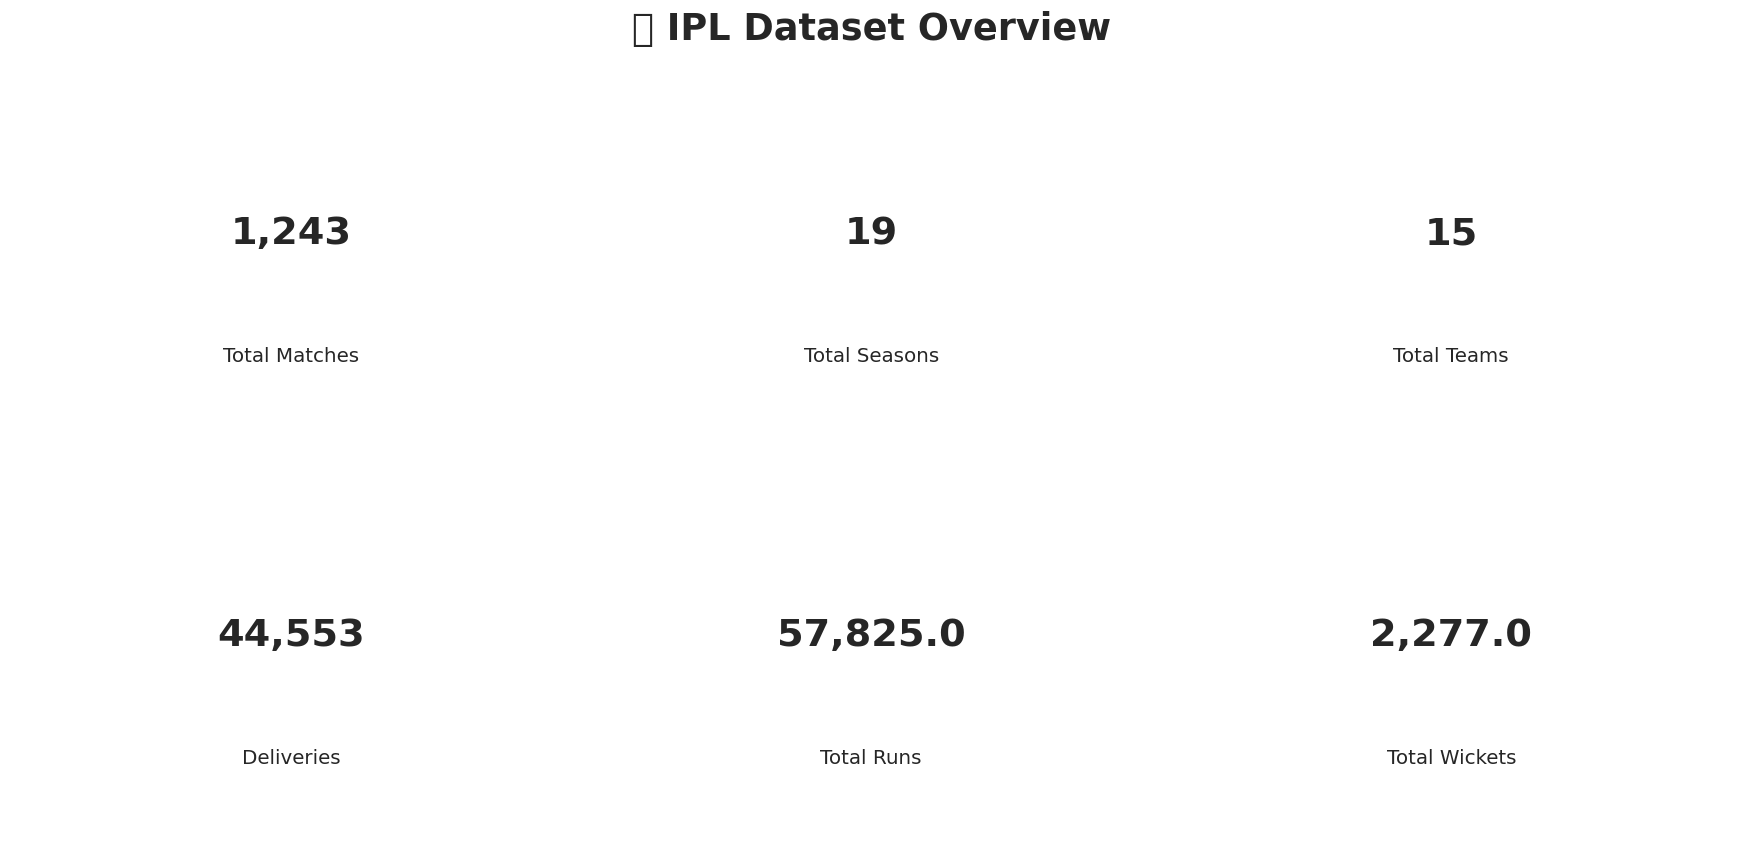

In [7]:
# ============================================================
# 7. KPI OVERVIEW
# ============================================================

total_matches = matches['match_id'].nunique() if 'match_id' in matches else len(matches)
total_deliveries = len(deliveries)
total_seasons = matches['season'].nunique() if 'season' in matches else 0

teams = set()
for col in ['team1', 'team2']:
    if col in matches.columns:
        teams.update(matches[col].dropna().unique())

total_teams = len(teams)
total_runs = deliveries['runs_total'].sum() if 'runs_total' in deliveries else 0
total_wickets = deliveries['wicket'].sum() if 'wicket' in deliveries else 0

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("🏏 IPL Dataset Overview", fontsize=24, fontweight="bold")

cards = [
    ("Total Matches", f"{total_matches:,}"),
    ("Total Seasons", f"{total_seasons:,}"),
    ("Total Teams", f"{total_teams:,}"),
    ("Deliveries", f"{total_deliveries:,}"),
    ("Total Runs", f"{total_runs:,}"),
    ("Total Wickets", f"{total_wickets:,}")
]

for ax, (title, value) in zip(axes.flat, cards):
    ax.axis("off")
    ax.text(0.5, 0.57, value, ha="center", va="center",
            fontsize=25, fontweight="bold")
    ax.text(0.5, 0.25, title, ha="center", va="center", fontsize=13)

plt.tight_layout()
plt.show()

## Visualization 1 — Matches per Season (Bar Chart)

/tmp/ipykernel_712/1389561713.py:14: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


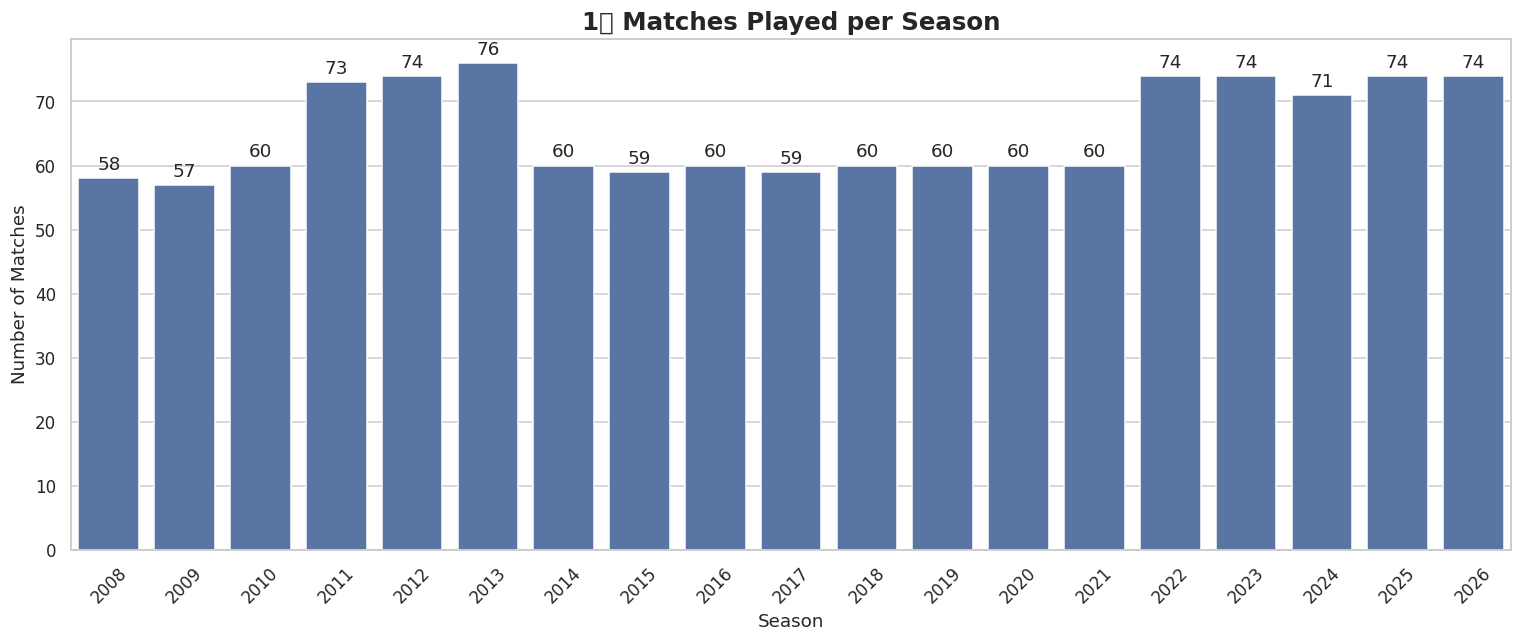

In [8]:
season_matches = matches['season'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
ax = sns.barplot(x=season_matches.index.astype(str),
                 y=season_matches.values)
plt.title("1️⃣ Matches Played per Season", fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

## Visualization 2 — Matches Trend (Line Chart)

/tmp/ipykernel_712/724736034.py:8: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


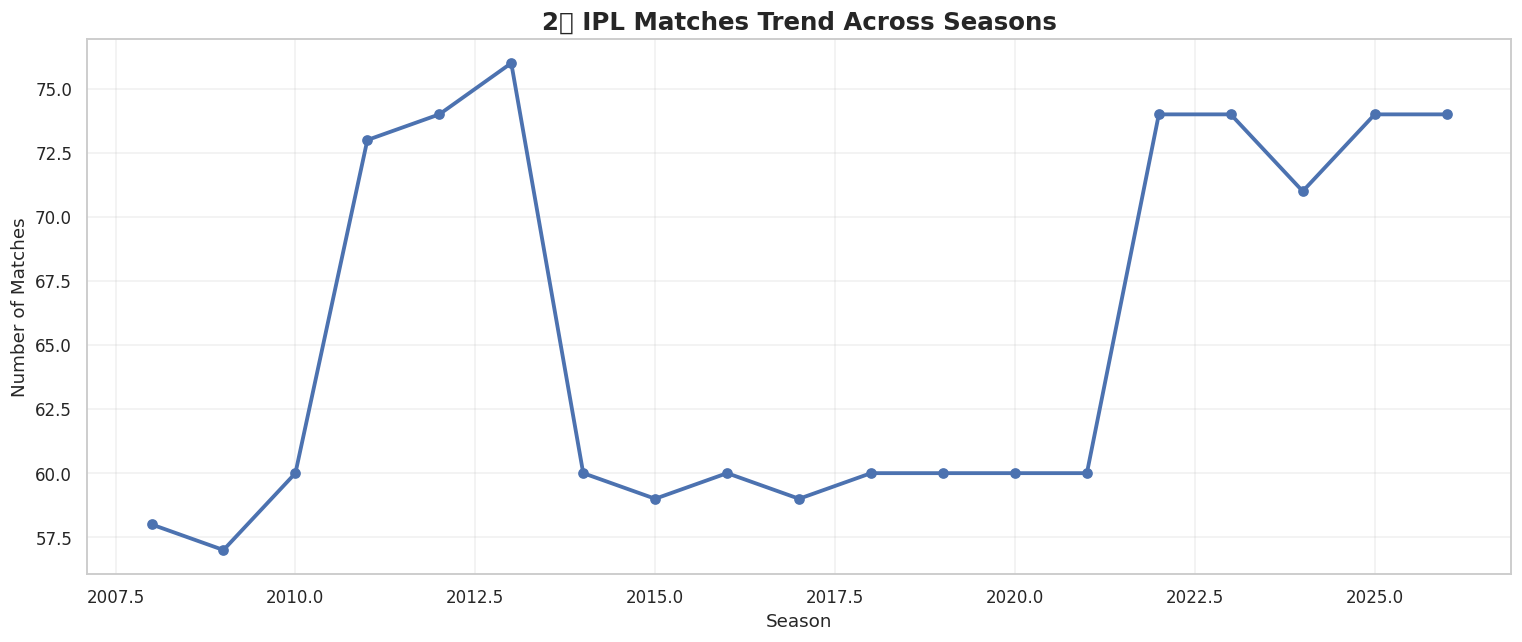

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(season_matches.index, season_matches.values,
         marker="o", linewidth=2.5)
plt.title("2️⃣ IPL Matches Trend Across Seasons", fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Visualization 3 — Toss Decision (Pie Chart)

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


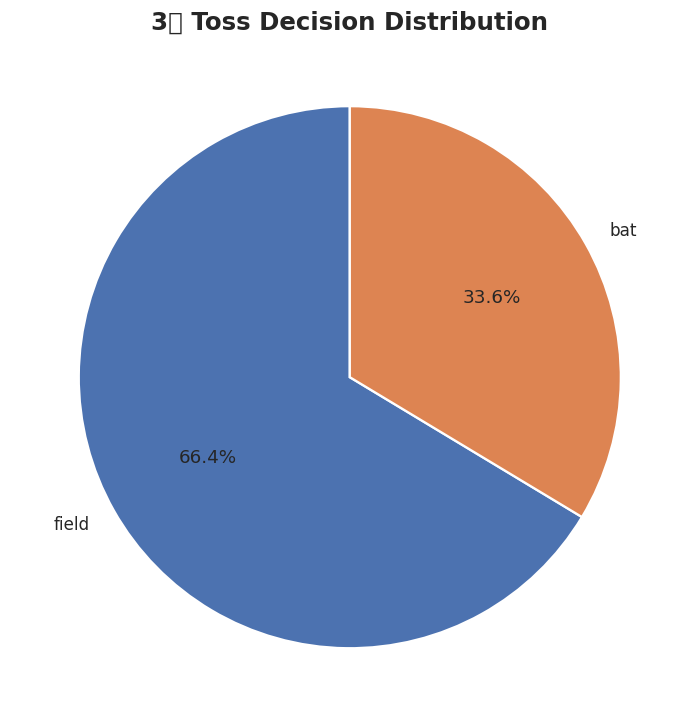

In [10]:
toss_decision = matches['toss_decision'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(toss_decision.values,
        labels=toss_decision.index,
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
plt.title("3️⃣ Toss Decision Distribution", fontweight="bold")
plt.show()

## Visualization 4 — Toss Winner vs Match Winner (Grouped Bar)

/tmp/ipykernel_712/2001303199.py:18: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


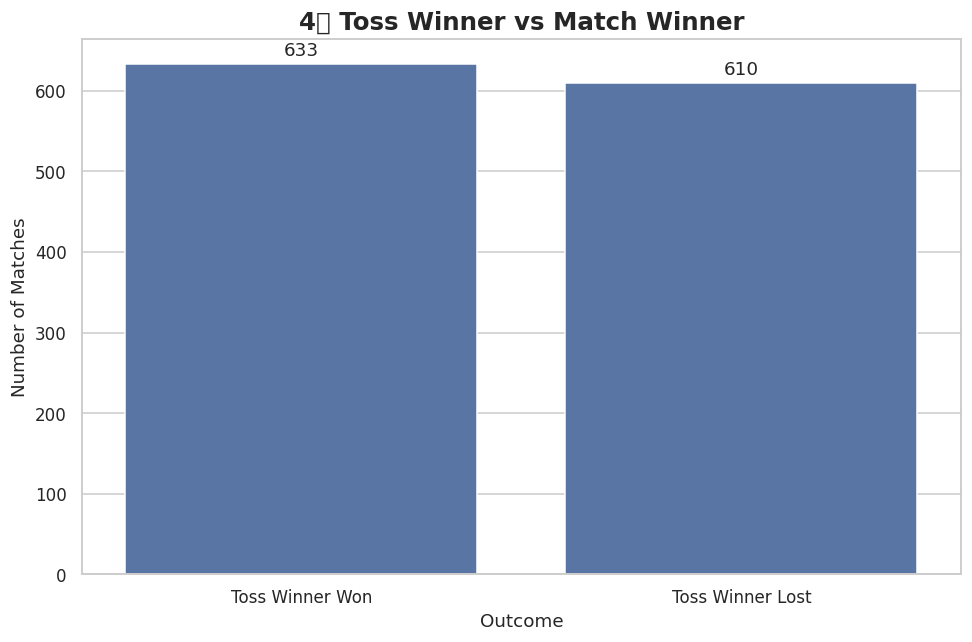

In [11]:
toss_match_win = (matches['toss_winner'] == matches['winner']).value_counts()

values = [
    toss_match_win.get(True, 0),
    toss_match_win.get(False, 0)
]
labels = ["Toss Winner Won", "Toss Winner Lost"]

plt.figure(figsize=(9, 6))
ax = sns.barplot(x=labels, y=values)
plt.title("4️⃣ Toss Winner vs Match Winner", fontweight="bold")
plt.xlabel("Outcome")
plt.ylabel("Number of Matches")

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

# 🏆 PART B — TEAM ANALYSIS

## Visualization 5 — Top Teams by Wins (Horizontal Bar)

/tmp/ipykernel_712/1592984773.py:12: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


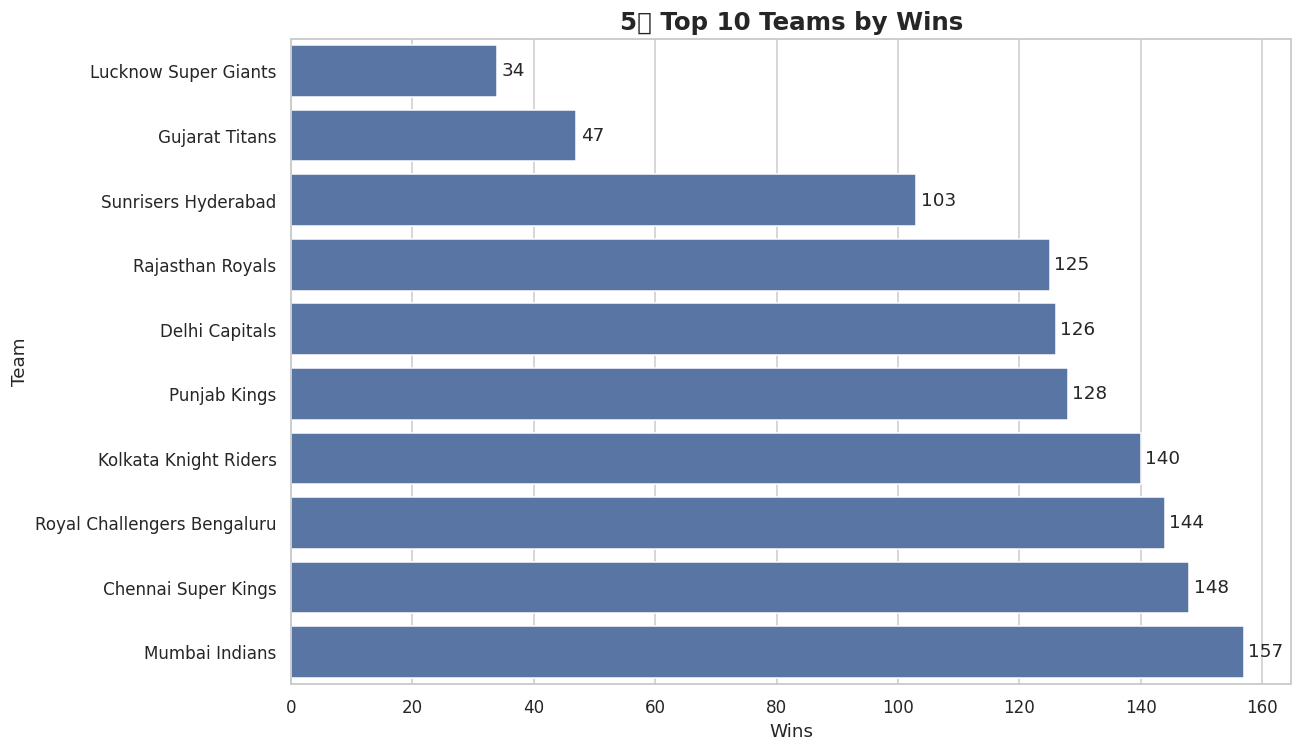

In [12]:
team_wins = matches['winner'].value_counts().head(10).sort_values()

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=team_wins.values, y=team_wins.index)
plt.title("5️⃣ Top 10 Teams by Wins", fontweight="bold")
plt.xlabel("Wins")
plt.ylabel("Team")

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

## Visualization 6 — Team Match Appearances (Horizontal Bar)

/tmp/ipykernel_712/1126362354.py:11: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


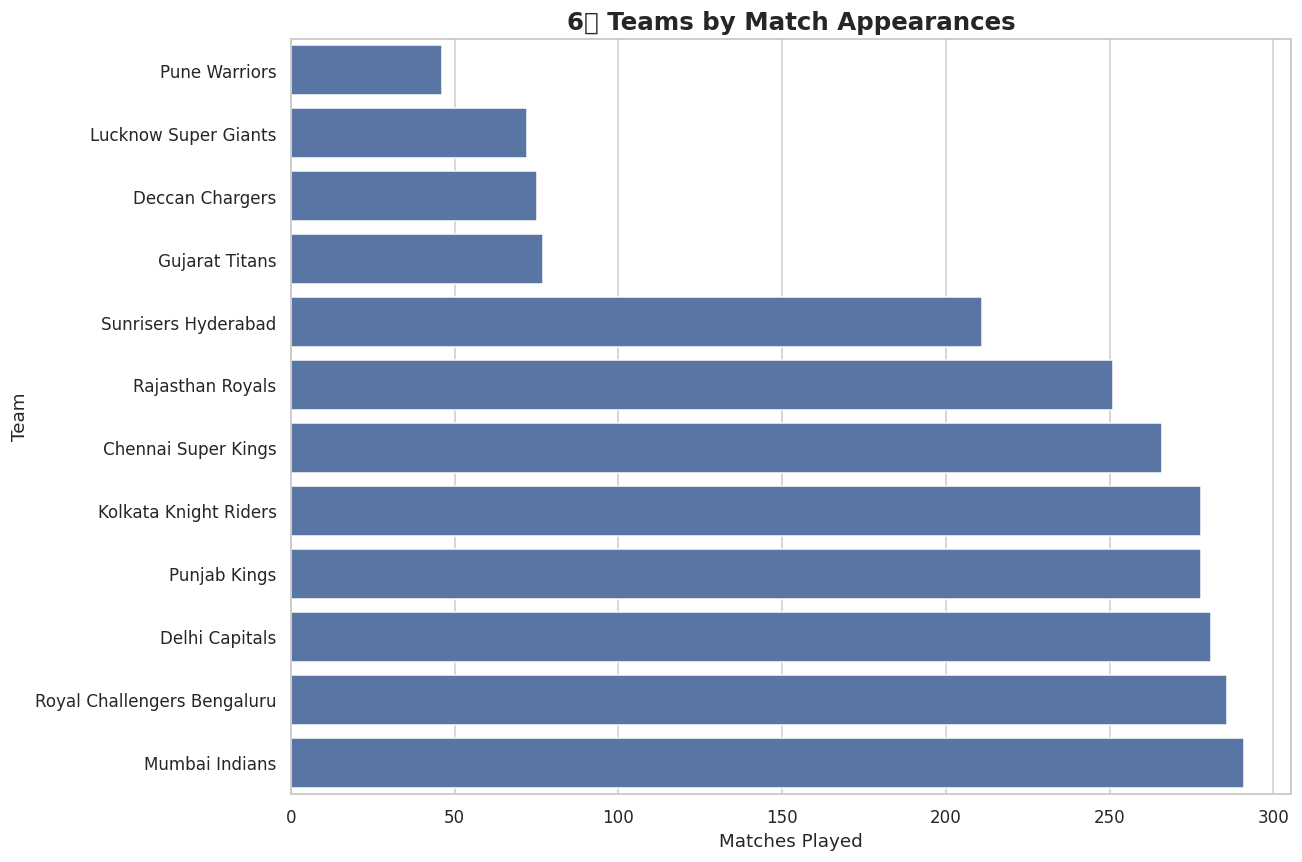

In [13]:
team_appearances = pd.concat([
    matches['team1'],
    matches['team2']
]).value_counts().head(12).sort_values()

plt.figure(figsize=(12, 8))
sns.barplot(x=team_appearances.values, y=team_appearances.index)
plt.title("6️⃣ Teams by Match Appearances", fontweight="bold")
plt.xlabel("Matches Played")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

## Visualization 7 — Team Win Percentage (Bar Chart)

/tmp/ipykernel_712/2067143740.py:15: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


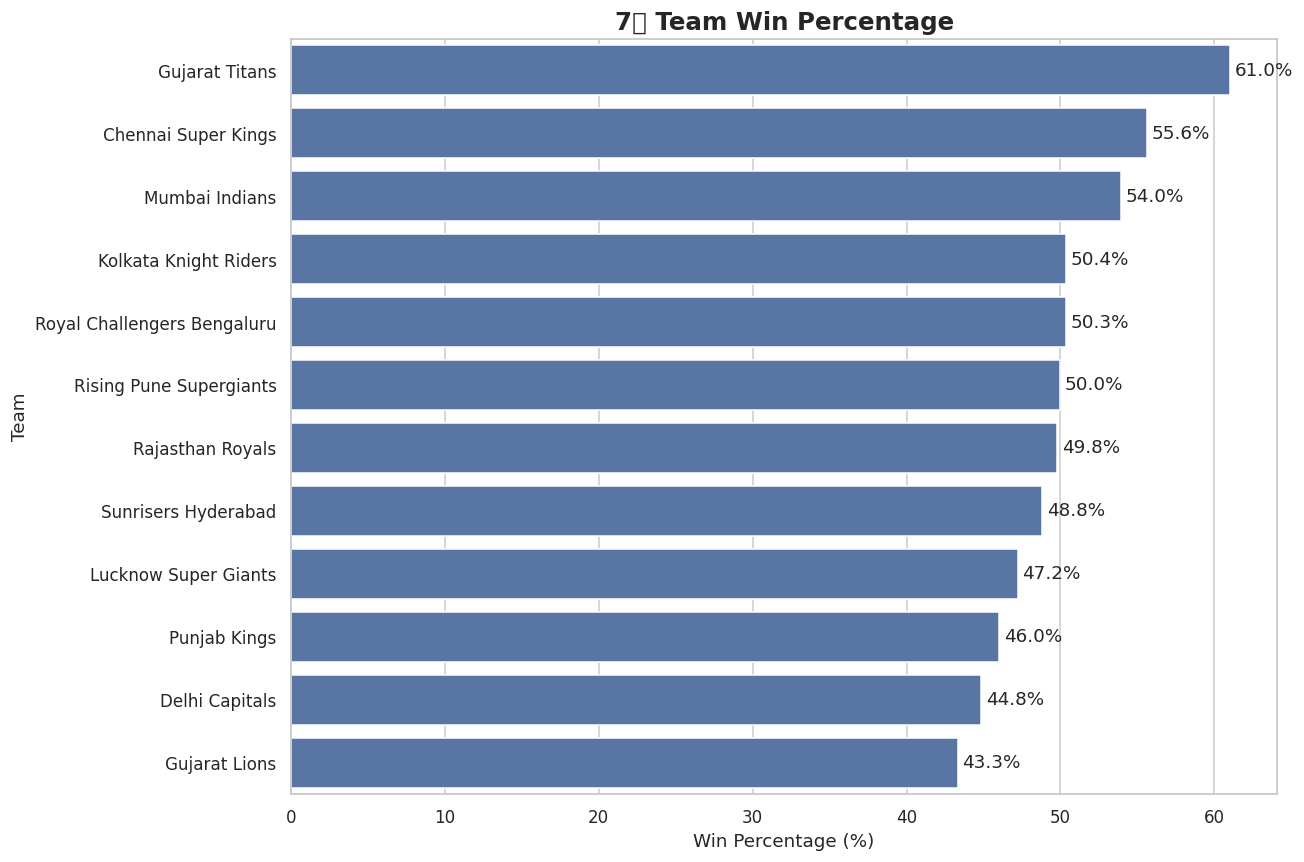

In [14]:
appearances = pd.concat([matches['team1'], matches['team2']]).value_counts()
wins = matches['winner'].value_counts()

win_pct = (wins / appearances * 100).dropna().sort_values(ascending=False).head(12)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=win_pct.values, y=win_pct.index)
plt.title("7️⃣ Team Win Percentage", fontweight="bold")
plt.xlabel("Win Percentage (%)")
plt.ylabel("Team")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

## Visualization 8 — Top Venues (Horizontal Bar)

/tmp/ipykernel_712/3686506223.py:8: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


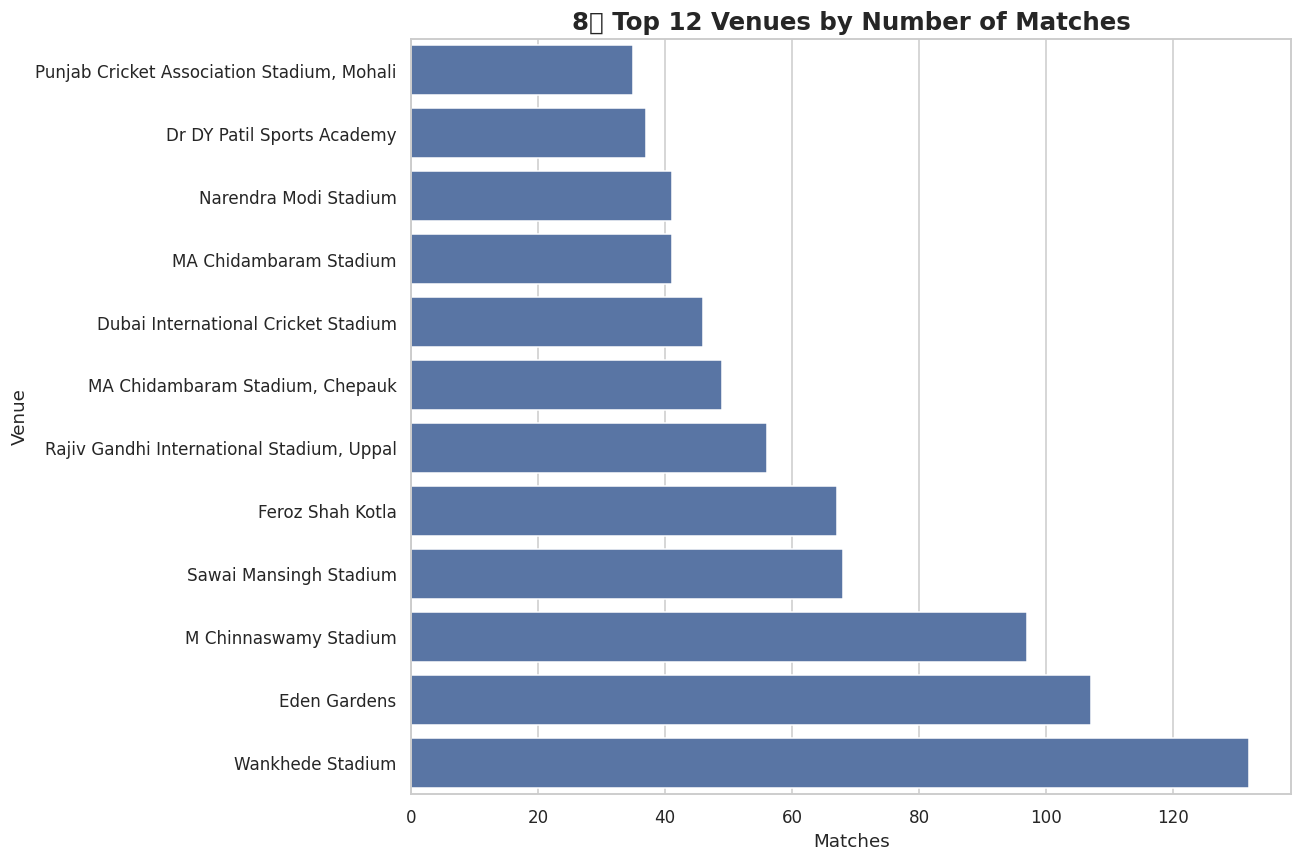

In [15]:
top_venues = matches['venue'].value_counts().head(12).sort_values()

plt.figure(figsize=(12, 8))
sns.barplot(x=top_venues.values, y=top_venues.index)
plt.title("8️⃣ Top 12 Venues by Number of Matches", fontweight="bold")
plt.xlabel("Matches")
plt.ylabel("Venue")
plt.tight_layout()
plt.show()

## Visualization 9 — Top Cities (Pie Chart)

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


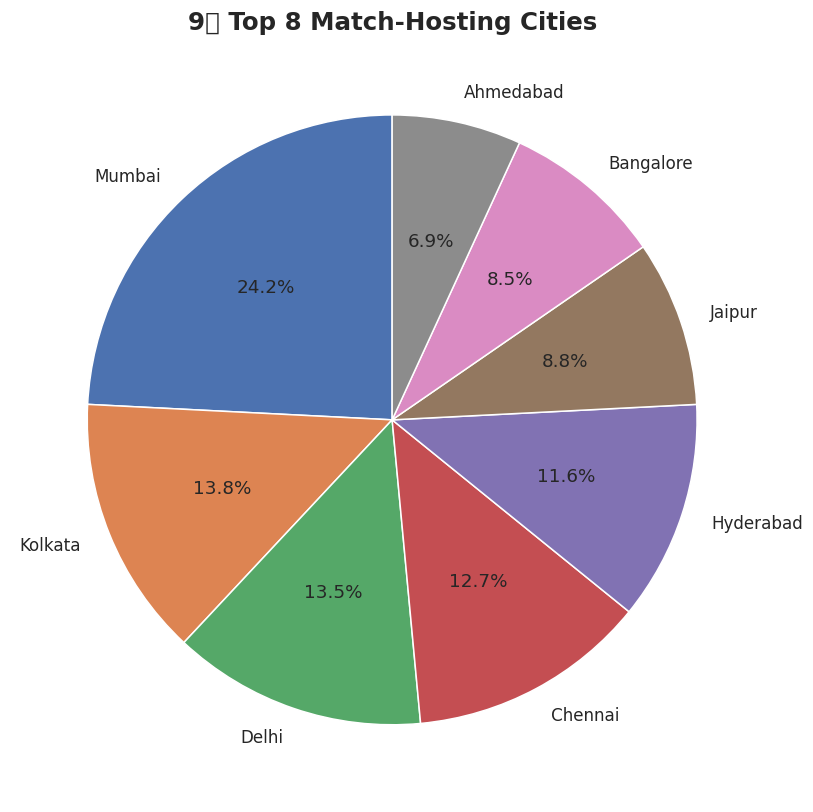

In [16]:
top_cities = matches['city'].value_counts().head(8)

plt.figure(figsize=(9, 9))
plt.pie(top_cities.values,
        labels=top_cities.index,
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white"})
plt.title("9️⃣ Top 8 Match-Hosting Cities", fontweight="bold")
plt.show()

# 🏏 PART C — BATTING ANALYSIS

## Visualization 10 — Top Batsmen by Runs (Bar Chart)

/tmp/ipykernel_712/2085072405.py:14: UserWarning: Glyph 128287 (\N{KEYCAP TEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128287 (\N{KEYCAP TEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


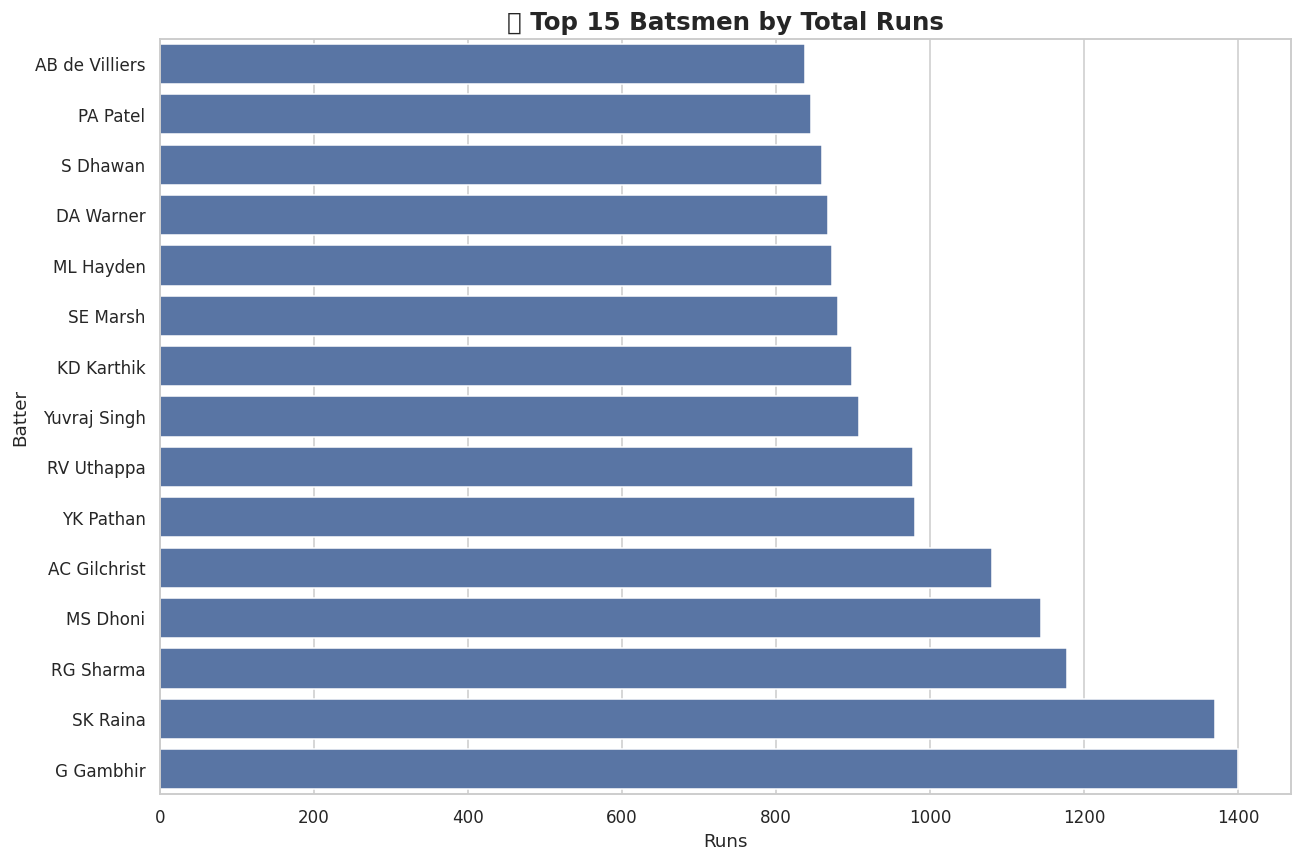

In [17]:
batter_runs = (
    deliveries.groupby('batter')['runs_batter']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 8))
sns.barplot(x=batter_runs.values, y=batter_runs.index)
plt.title("🔟 Top 15 Batsmen by Total Runs", fontweight="bold")
plt.xlabel("Runs")
plt.ylabel("Batter")
plt.tight_layout()
plt.show()

## Visualization 11 — Batter Runs Distribution (Histogram + KDE)

/tmp/ipykernel_712/2329714703.py:9: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


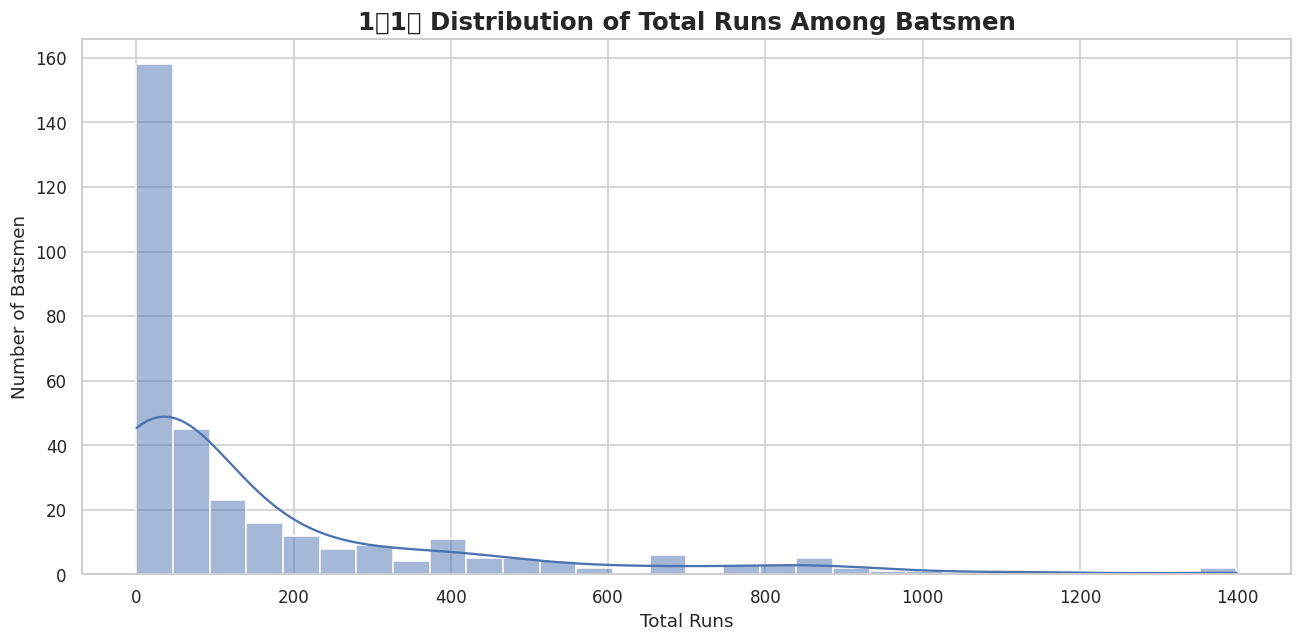

In [18]:
player_total_runs = deliveries.groupby('batter')['runs_batter'].sum()

plt.figure(figsize=(12, 6))
sns.histplot(player_total_runs, bins=30, kde=True)
plt.title("1️⃣1️⃣ Distribution of Total Runs Among Batsmen",
          fontweight="bold")
plt.xlabel("Total Runs")
plt.ylabel("Number of Batsmen")
plt.tight_layout()
plt.show()

## Visualization 12 — Runs per Delivery (Box Plot)

/tmp/ipykernel_712/1866125212.py:6: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


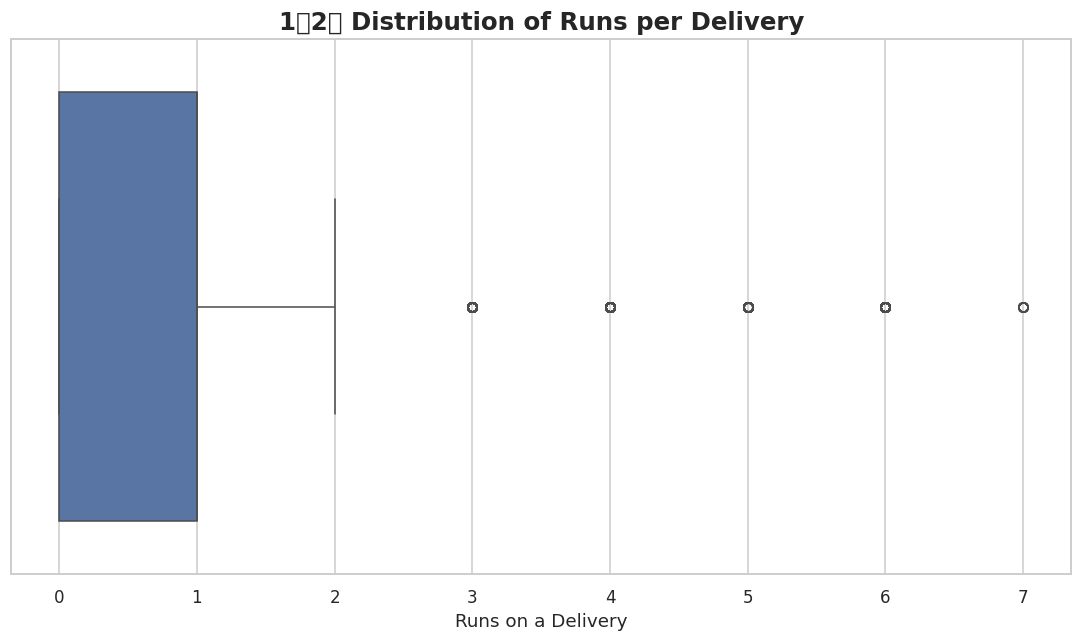

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=deliveries['runs_total'])
plt.title("1️⃣2️⃣ Distribution of Runs per Delivery",
          fontweight="bold")
plt.xlabel("Runs on a Delivery")
plt.tight_layout()
plt.show()

## Visualization 13 — Batter Runs vs Balls Faced (Scatter Plot)

/tmp/ipykernel_712/4167650926.py:27: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


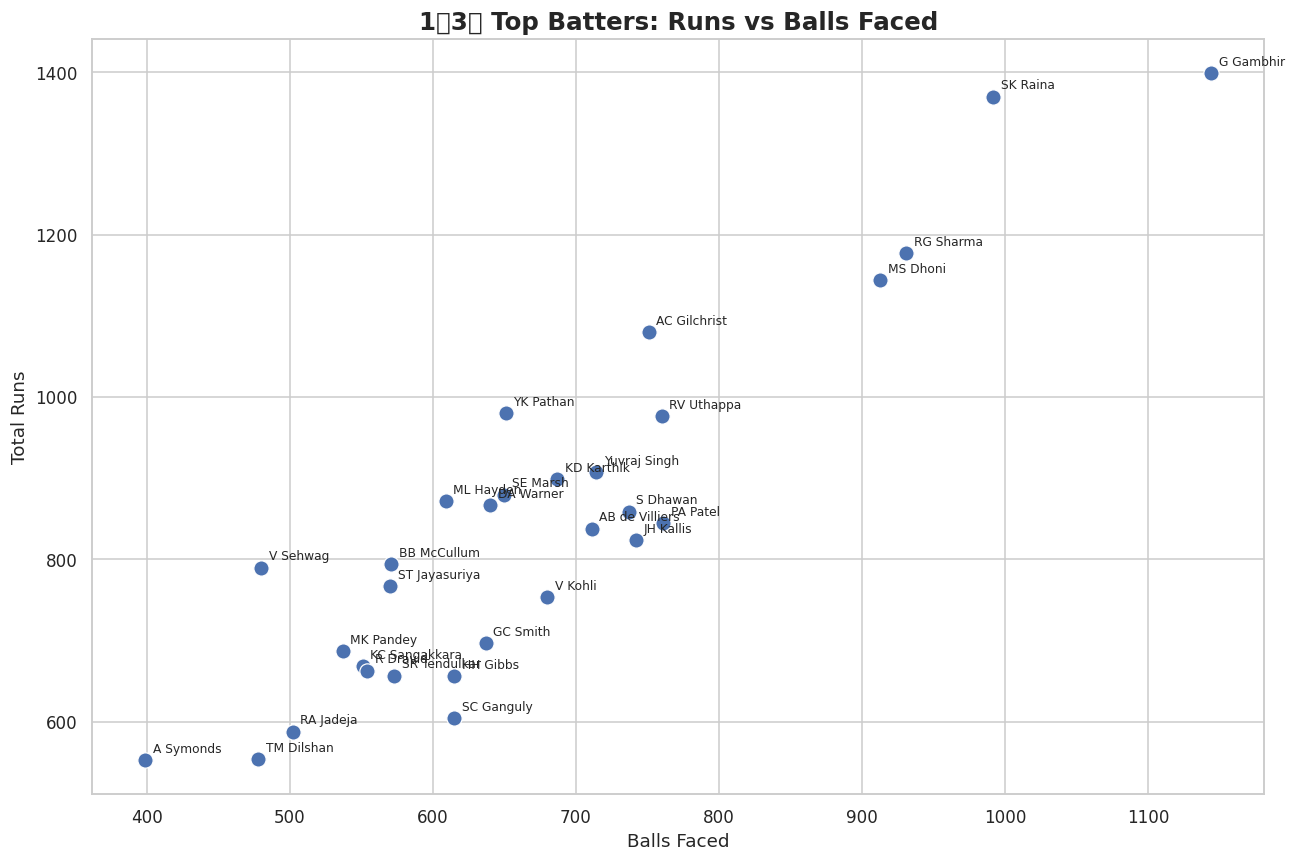

In [20]:
batter_stats = deliveries.groupby('batter').agg(
    total_runs=('runs_batter', 'sum'),
    balls_faced=('batter', 'count')
).sort_values('total_runs', ascending=False).head(30)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=batter_stats,
    x='balls_faced',
    y='total_runs',
    s=100
)

for player, row in batter_stats.iterrows():
    plt.annotate(
        player,
        (row['balls_faced'], row['total_runs']),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title("1️⃣3️⃣ Top Batters: Runs vs Balls Faced",
          fontweight="bold")
plt.xlabel("Balls Faced")
plt.ylabel("Total Runs")
plt.tight_layout()
plt.show()

## Visualization 14 — Fours vs Sixes (Pie Chart)

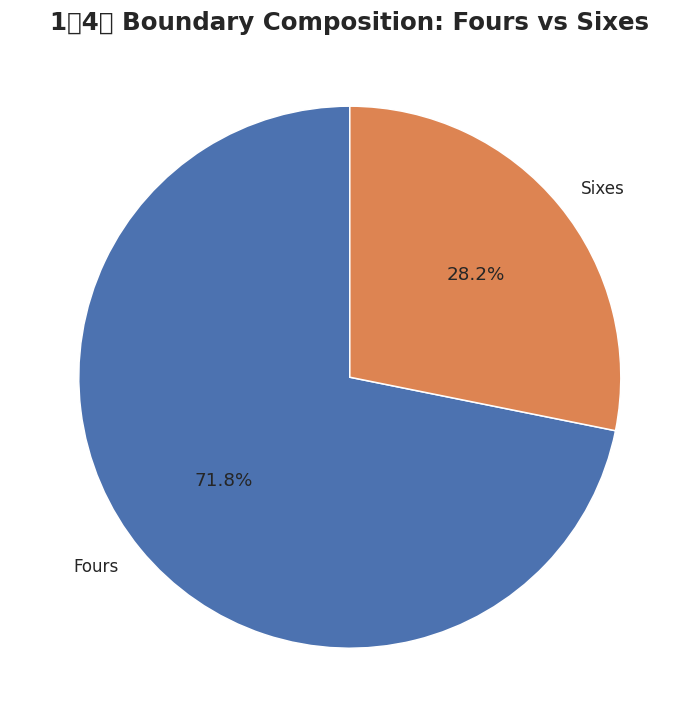

In [21]:
fours = (deliveries['runs_batter'] == 4).sum()
sixes = (deliveries['runs_batter'] == 6).sum()

boundary_counts = pd.Series({"Fours": fours, "Sixes": sixes})

plt.figure(figsize=(8, 8))
plt.pie(boundary_counts.values,
        labels=boundary_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white"})
plt.title("1️⃣4️⃣ Boundary Composition: Fours vs Sixes",
          fontweight="bold")
plt.show()

## Visualization 15 — Top 10 Boundary Hitters (Bar Chart)

/tmp/ipykernel_712/4056920301.py:16: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


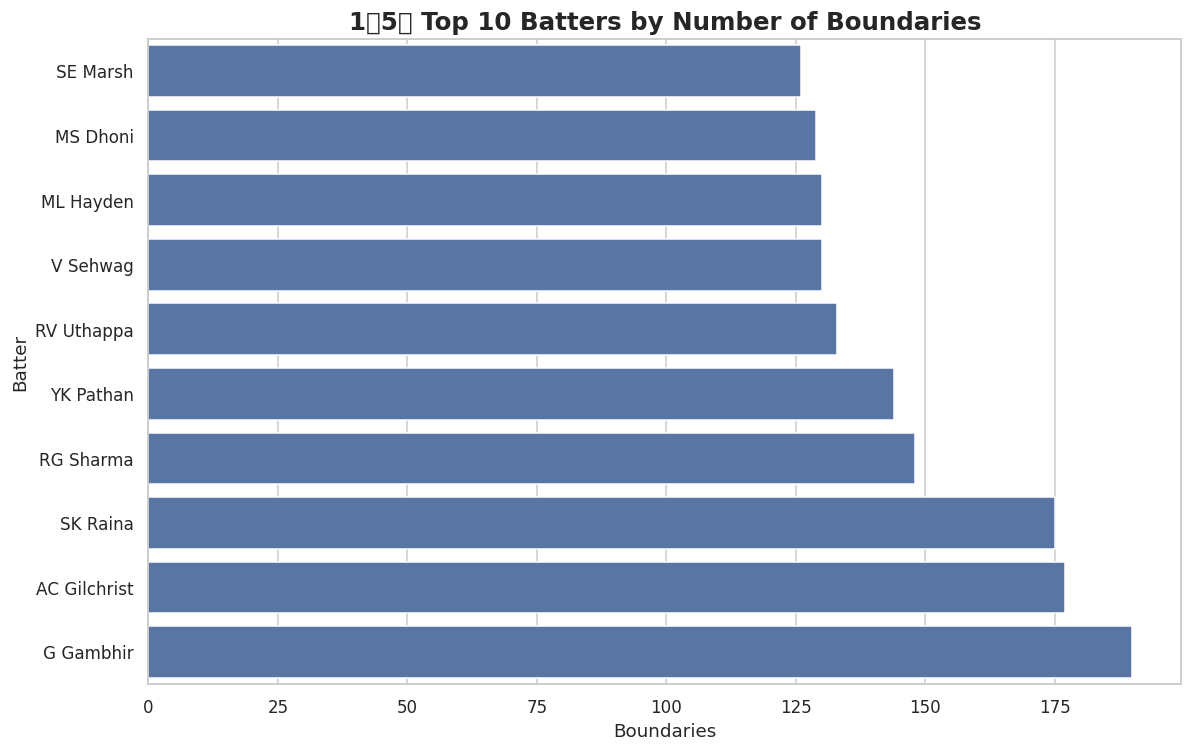

In [22]:
boundary_hitters = (
    deliveries[deliveries['runs_batter'].isin([4, 6])]
    .groupby('batter')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(11, 7))
sns.barplot(x=boundary_hitters.values, y=boundary_hitters.index)
plt.title("1️⃣5️⃣ Top 10 Batters by Number of Boundaries",
          fontweight="bold")
plt.xlabel("Boundaries")
plt.ylabel("Batter")
plt.tight_layout()
plt.show()

# 🎯 PART D — BOWLING & WICKETS

## Visualization 16 — Top Bowlers by Wickets (Bar Chart)

/tmp/ipykernel_712/2308178592.py:15: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


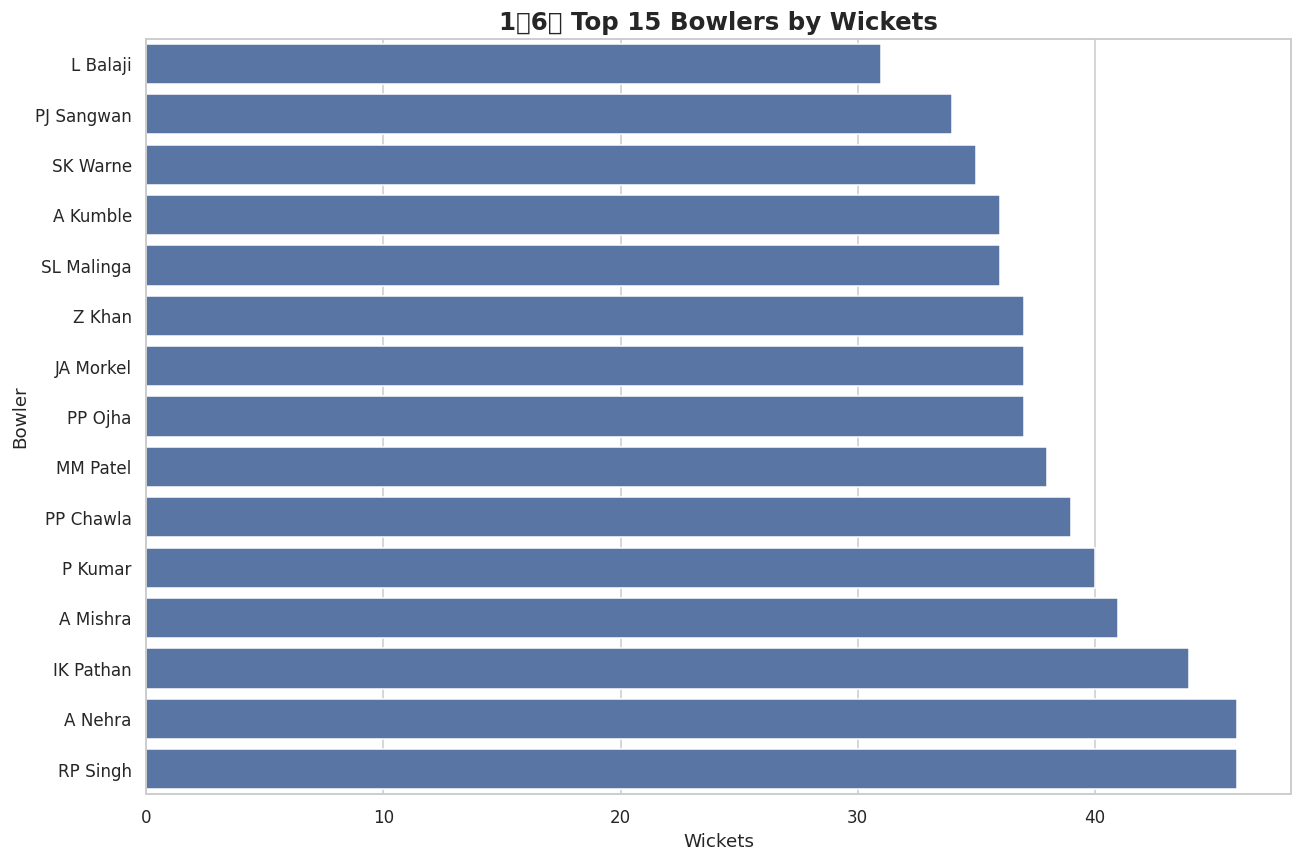

In [23]:
bowler_wickets = (
    deliveries[deliveries['wicket'] == 1]
    .groupby('bowler')
    .size()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 8))
sns.barplot(x=bowler_wickets.values, y=bowler_wickets.index)
plt.title("1️⃣6️⃣ Top 15 Bowlers by Wickets", fontweight="bold")
plt.xlabel("Wickets")
plt.ylabel("Bowler")
plt.tight_layout()
plt.show()

## Visualization 17 — Dismissal Types (Pie Chart)

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


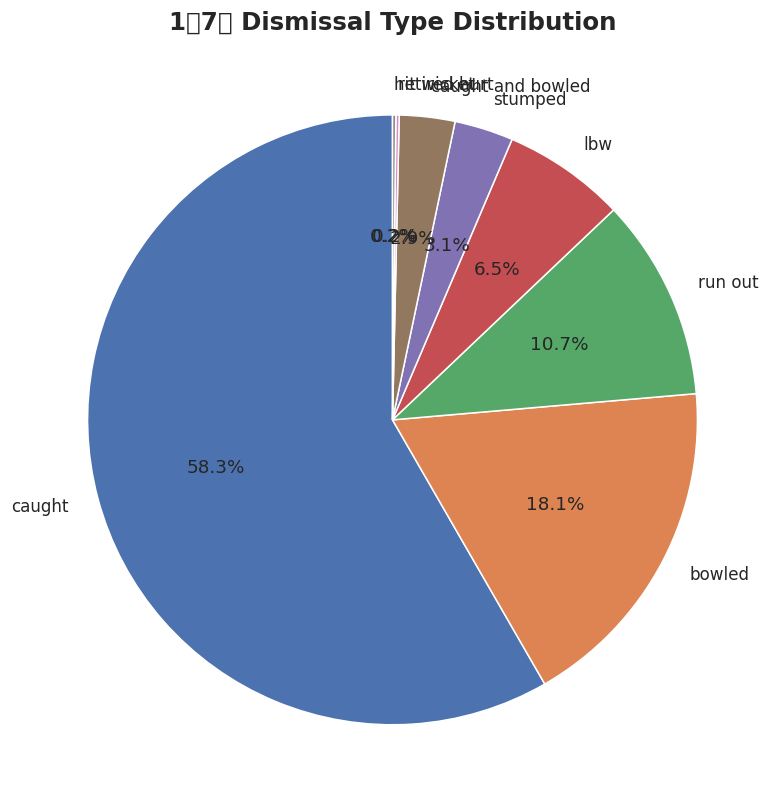

In [24]:
dismissals = (
    deliveries[deliveries['wicket_kind'].notna()]
    ['wicket_kind']
    .value_counts()
)

plt.figure(figsize=(9, 9))
plt.pie(dismissals.values,
        labels=dismissals.index,
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white"})
plt.title("1️⃣7️⃣ Dismissal Type Distribution", fontweight="bold")
plt.show()

## Visualization 18 — Dismissal Types (Horizontal Bar)

/tmp/ipykernel_712/2825416943.py:8: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


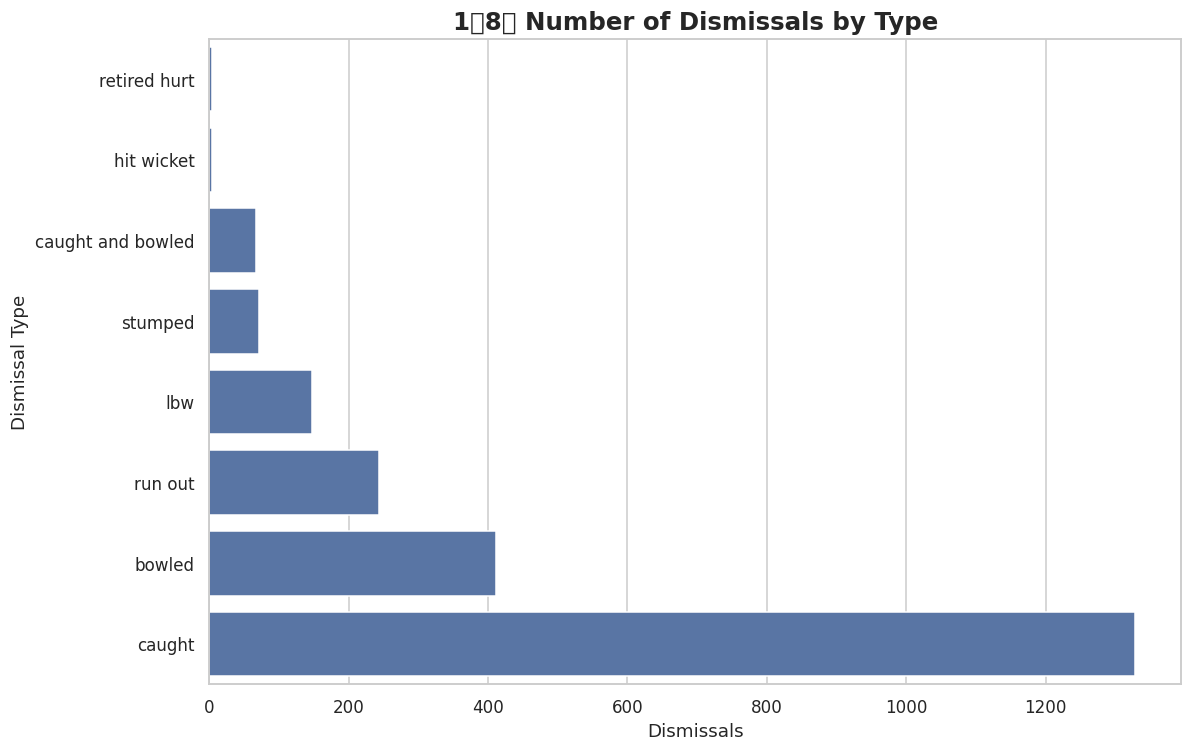

In [25]:
dismissals_sorted = dismissals.sort_values()

plt.figure(figsize=(11, 7))
sns.barplot(x=dismissals_sorted.values, y=dismissals_sorted.index)
plt.title("1️⃣8️⃣ Number of Dismissals by Type", fontweight="bold")
plt.xlabel("Dismissals")
plt.ylabel("Dismissal Type")
plt.tight_layout()
plt.show()

# 🔥 PART E — RUN & SCORING ANALYSIS

## Visualization 19 — Total Runs by Season (Line Chart)

/tmp/ipykernel_712/1408680899.py:10: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


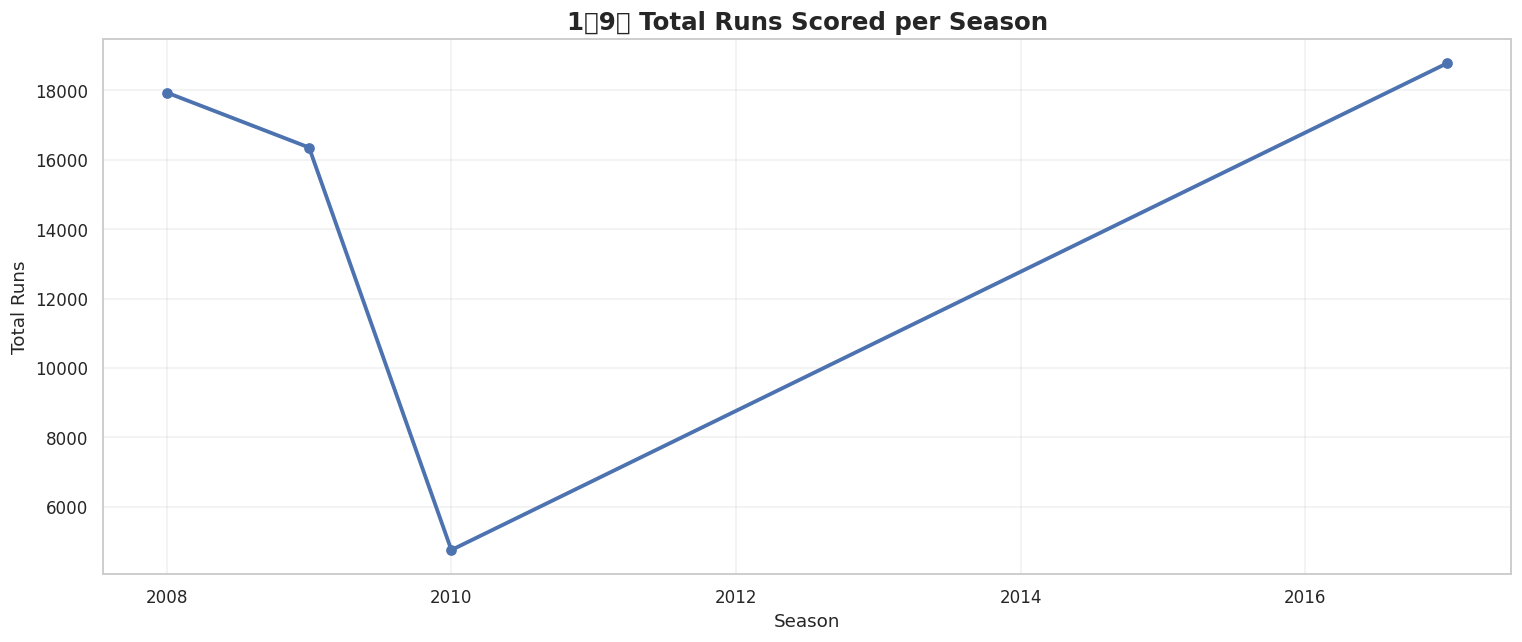

In [26]:
season_runs = combined.groupby('season')['runs_total'].sum()

plt.figure(figsize=(14, 6))
plt.plot(season_runs.index, season_runs.values,
         marker='o', linewidth=2.5)
plt.title("1️⃣9️⃣ Total Runs Scored per Season", fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Visualization 20 — Runs by Over (Line Chart)

/tmp/ipykernel_712/2852953856.py:10: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


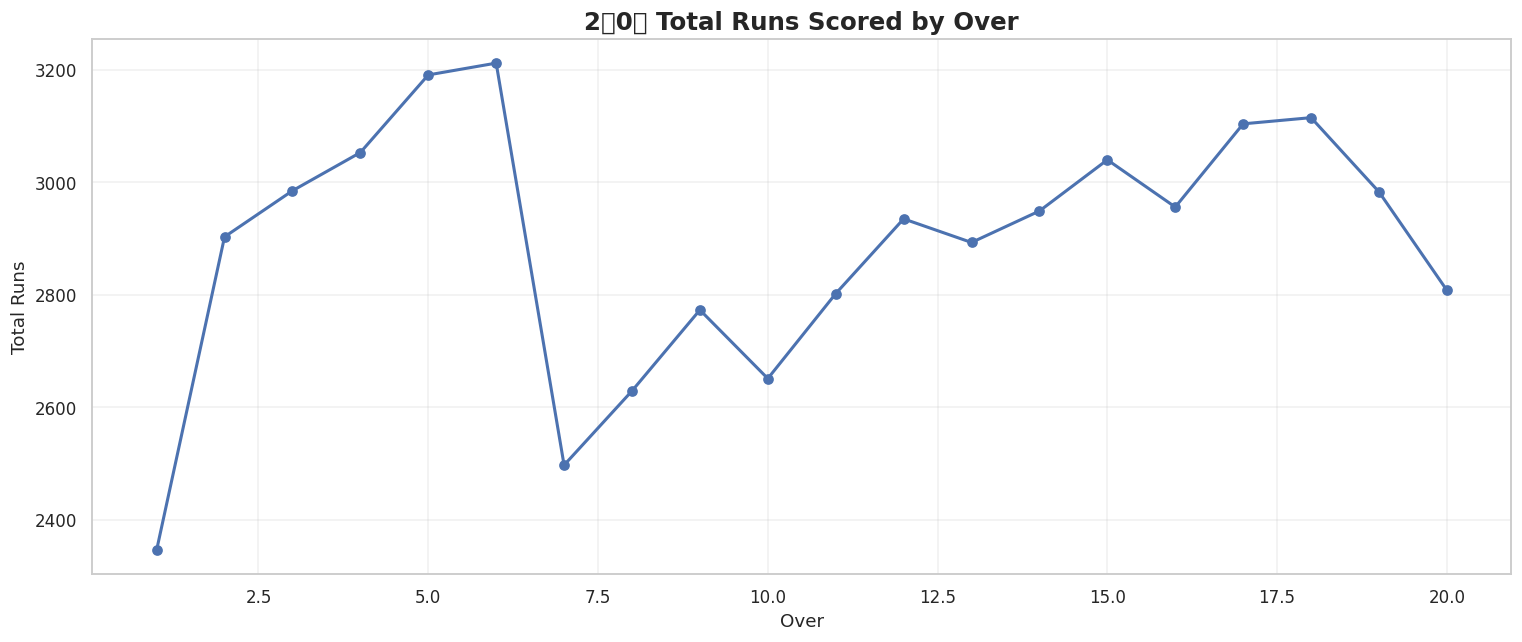

In [27]:
over_runs = deliveries.groupby('over')['runs_total'].sum()

plt.figure(figsize=(14, 6))
plt.plot(over_runs.index, over_runs.values,
         marker='o', linewidth=2)
plt.title("2️⃣0️⃣ Total Runs Scored by Over", fontweight="bold")
plt.xlabel("Over")
plt.ylabel("Total Runs")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Visualization 21 — Runs by Over (Area Chart)

/tmp/ipykernel_712/1706301430.py:9: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


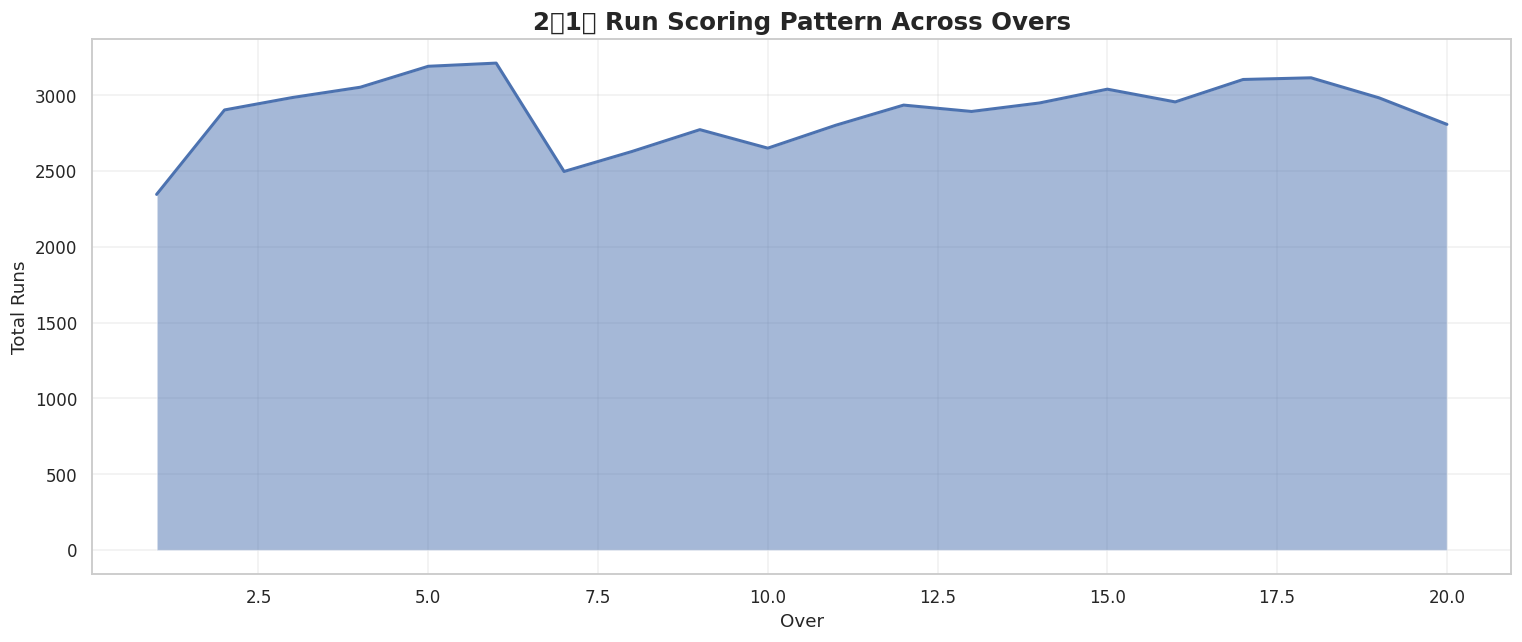

In [28]:
plt.figure(figsize=(14, 6))
plt.fill_between(over_runs.index, over_runs.values, alpha=0.5)
plt.plot(over_runs.index, over_runs.values, linewidth=2)
plt.title("2️⃣1️⃣ Run Scoring Pattern Across Overs",
          fontweight="bold")
plt.xlabel("Over")
plt.ylabel("Total Runs")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Visualization 22 — Runs per Delivery (Histogram)

/tmp/ipykernel_712/2724840752.py:7: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


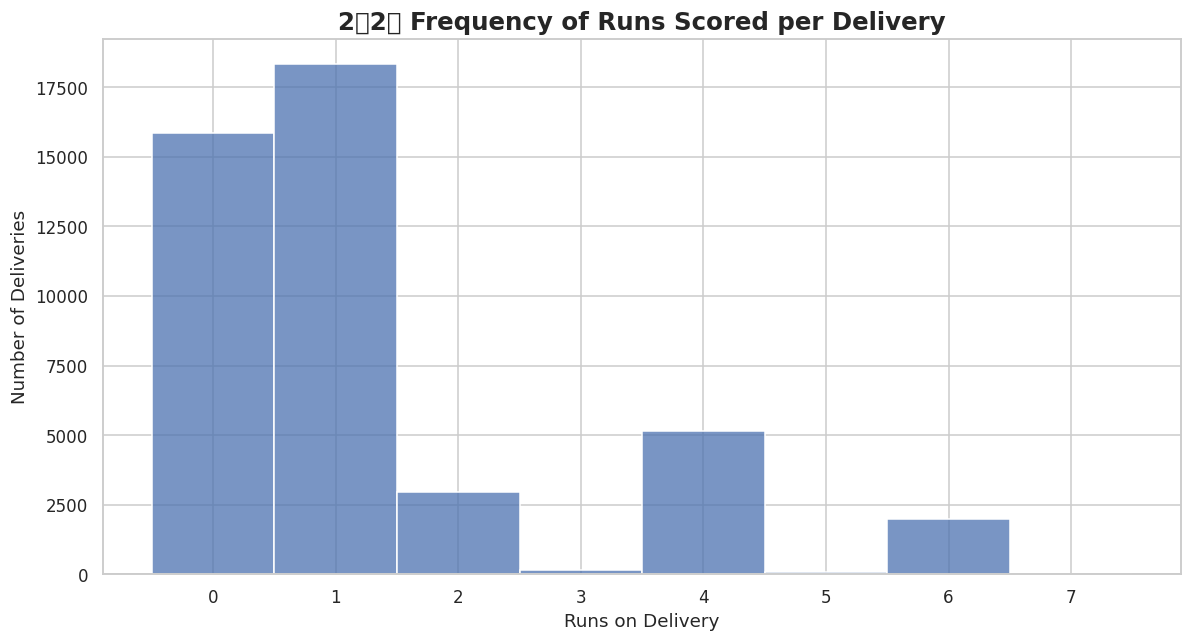

In [29]:
plt.figure(figsize=(11, 6))
sns.histplot(deliveries['runs_total'], discrete=True, kde=False)
plt.title("2️⃣2️⃣ Frequency of Runs Scored per Delivery",
          fontweight="bold")
plt.xlabel("Runs on Delivery")
plt.ylabel("Number of Deliveries")
plt.tight_layout()
plt.show()

## Visualization 23 — Batter Runs vs Extra Runs (Pie Chart)

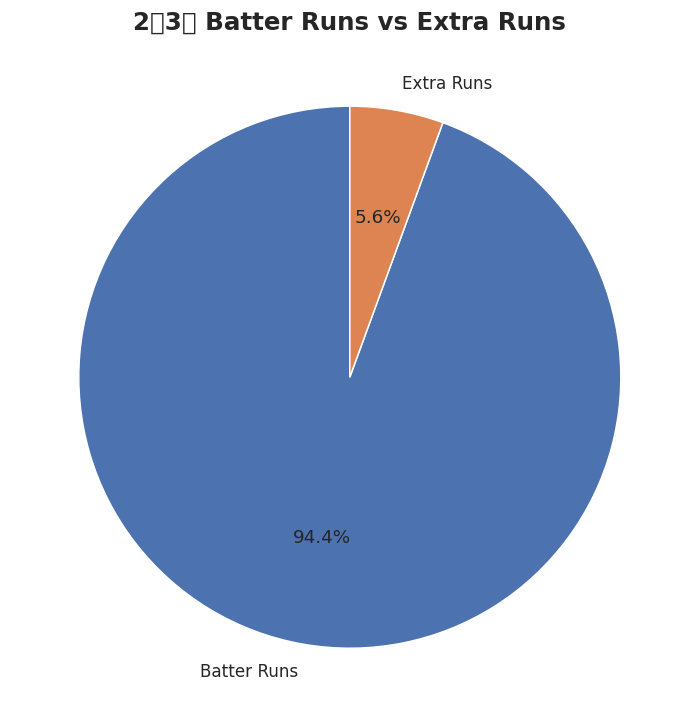

In [30]:
run_parts = pd.Series({
    "Batter Runs": deliveries['runs_batter'].sum(),
    "Extra Runs": deliveries['runs_extras'].sum()
})

plt.figure(figsize=(8, 8))
plt.pie(run_parts.values,
        labels=run_parts.index,
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white"})
plt.title("2️⃣3️⃣ Batter Runs vs Extra Runs", fontweight="bold")
plt.show()

# 📈 PART F — SEASON & TEAM COMPARISON

## Visualization 24 — Average Runs per Match by Season

/tmp/ipykernel_712/3655884462.py:21: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


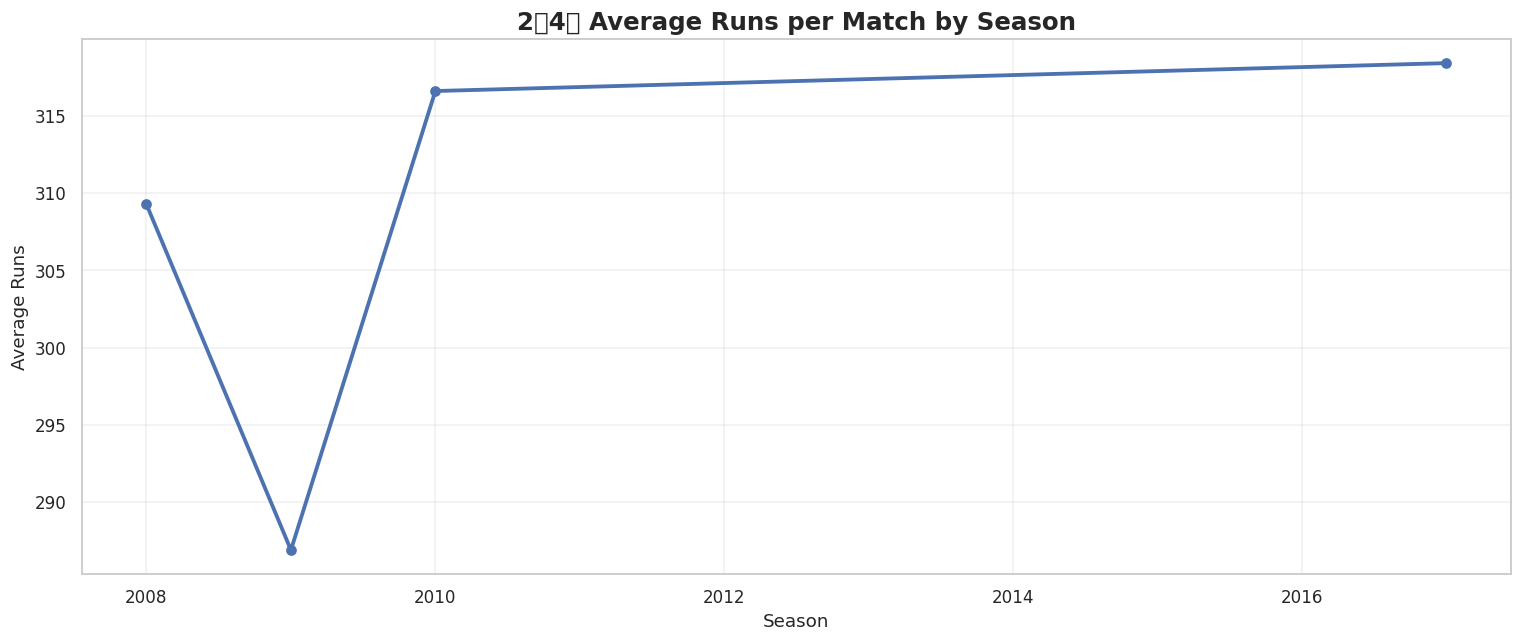

In [31]:
match_run_totals = (
    combined.groupby(['season', 'match_id'])['runs_total']
    .sum()
    .reset_index()
)

avg_runs_per_match = (
    match_run_totals.groupby('season')['runs_total']
    .mean()
)

plt.figure(figsize=(14, 6))
plt.plot(avg_runs_per_match.index,
         avg_runs_per_match.values,
         marker='o', linewidth=2.5)
plt.title("2️⃣4️⃣ Average Runs per Match by Season",
          fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Average Runs")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Visualization 25 — Top Teams' Runs Across Seasons (Multi-Line)

/tmp/ipykernel_712/2331282395.py:32: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


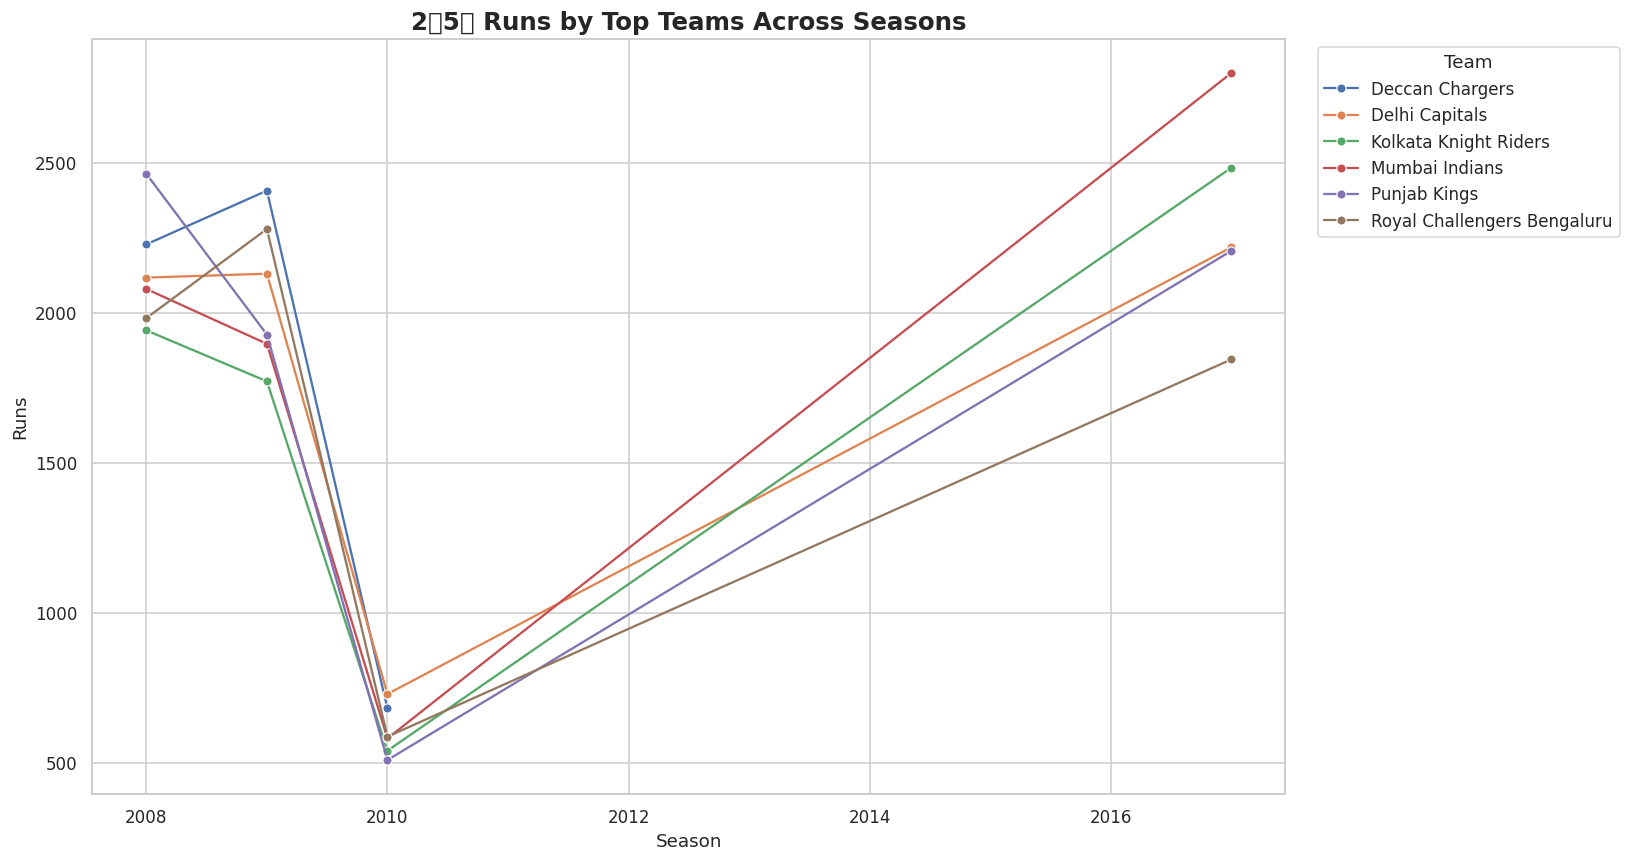

In [32]:
team_season_runs = (
    combined.groupby(['season', 'batting_team'])['runs_total']
    .sum()
    .reset_index()
)

top_teams = (
    combined.groupby('batting_team')['runs_total']
    .sum()
    .nlargest(6)
    .index
)

plot_data = team_season_runs[
    team_season_runs['batting_team'].isin(top_teams)
]

plt.figure(figsize=(15, 8))
sns.lineplot(
    data=plot_data,
    x='season',
    y='runs_total',
    hue='batting_team',
    marker='o'
)

plt.title("2️⃣5️⃣ Runs by Top Teams Across Seasons",
          fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Runs")
plt.legend(title="Team", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Visualization 26 — Team Runs Comparison (Bar Chart)

/tmp/ipykernel_712/400432104.py:12: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


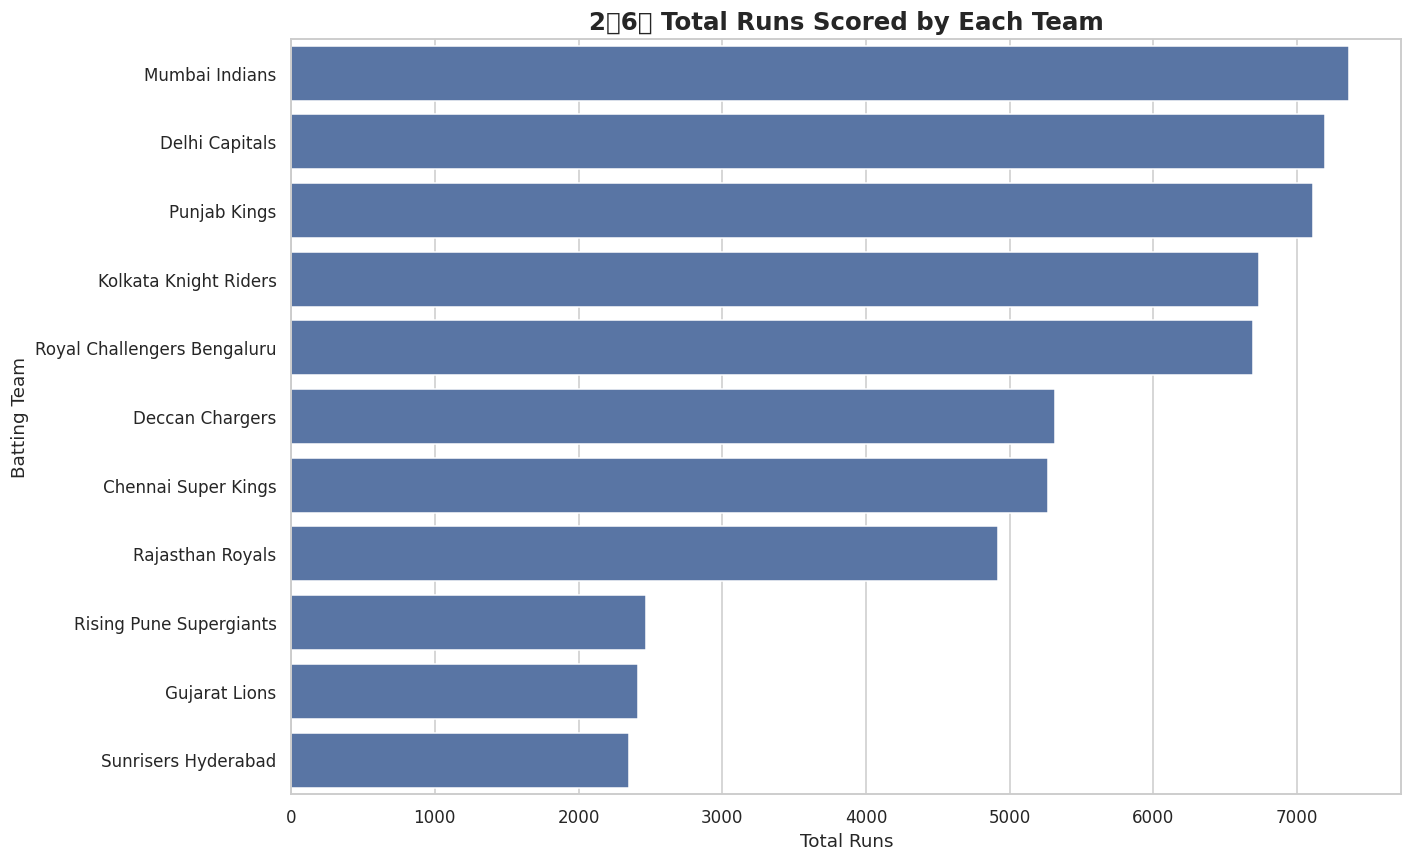

In [33]:
team_runs = (
    deliveries.groupby('batting_team')['runs_total']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(13, 8))
sns.barplot(x=team_runs.values, y=team_runs.index)
plt.title("2️⃣6️⃣ Total Runs Scored by Each Team", fontweight="bold")
plt.xlabel("Total Runs")
plt.ylabel("Batting Team")
plt.tight_layout()
plt.show()

# 🔬 PART G — ADVANCED VISUALIZATIONS

## Visualization 27 — Correlation Heatmap

/tmp/ipykernel_712/1804705814.py:21: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


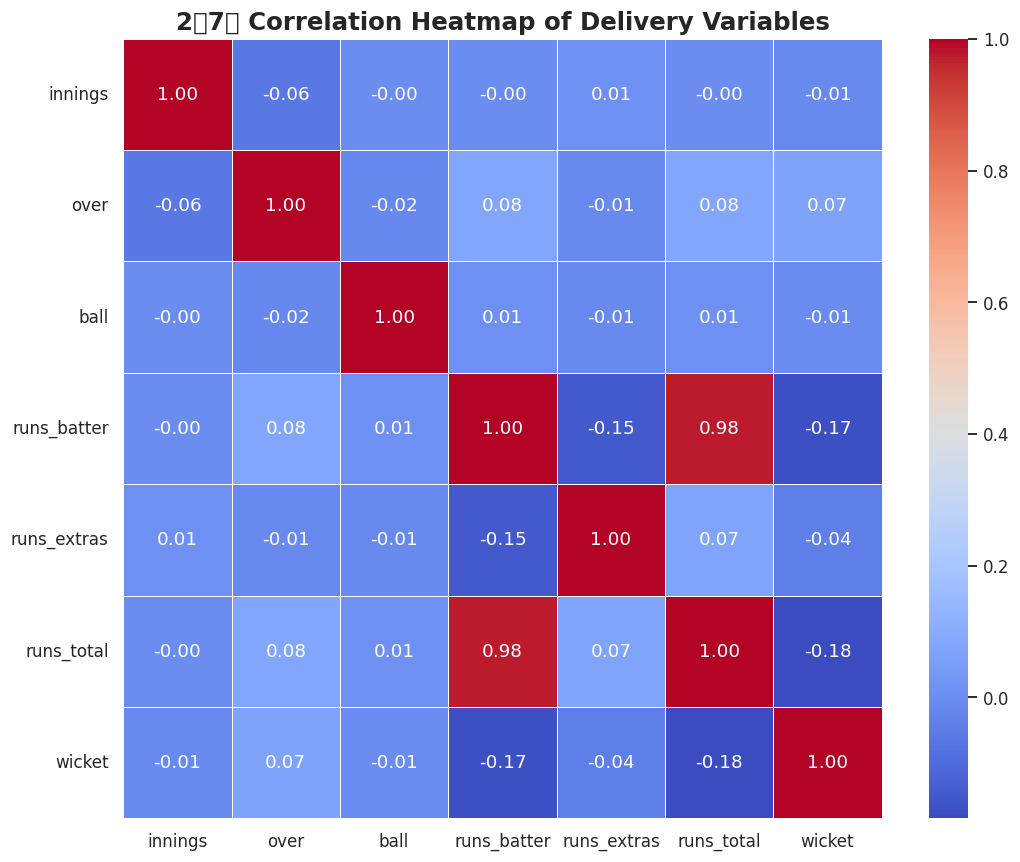

In [34]:
numeric_cols = [
    c for c in [
        'innings', 'over', 'ball',
        'runs_batter', 'runs_extras',
        'runs_total', 'wicket'
    ] if c in deliveries.columns
]

corr = deliveries[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("2️⃣7️⃣ Correlation Heatmap of Delivery Variables",
          fontweight="bold")
plt.tight_layout()
plt.show()

## Visualization 28 — Runs per Over Distribution (Histogram + KDE)

/tmp/ipykernel_712/2714722475.py:15: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


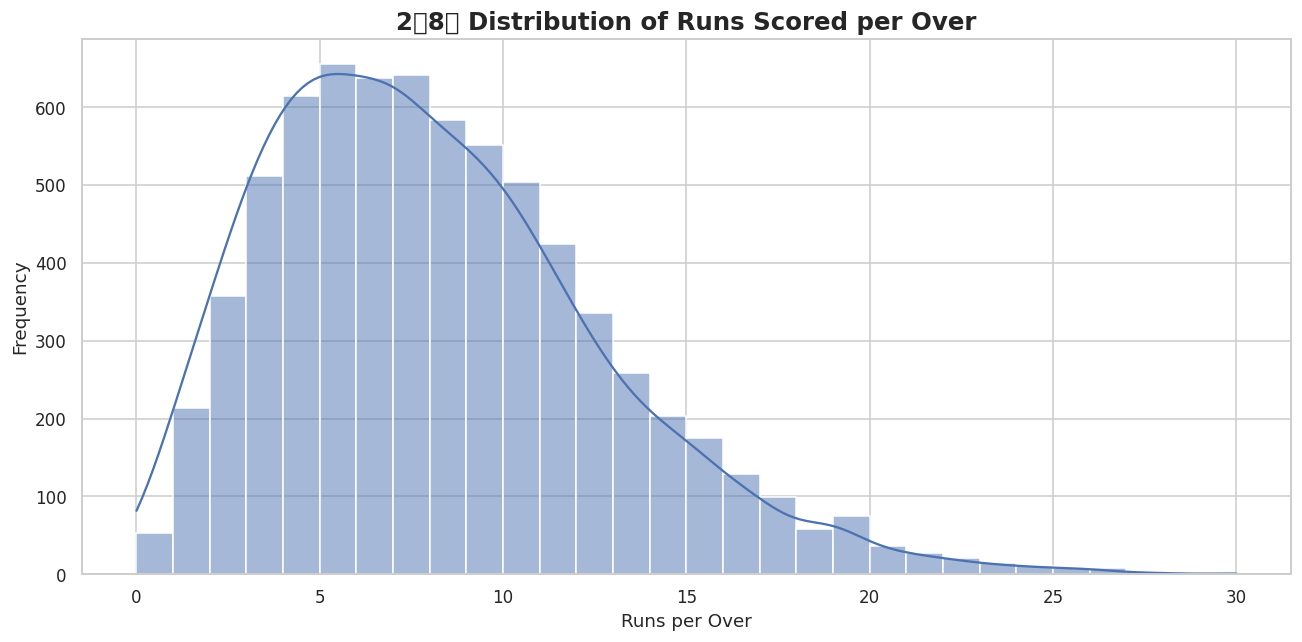

In [35]:
over_match = (
    deliveries.groupby(['match_id', 'innings', 'over'])['runs_total']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.histplot(over_match['runs_total'],
             bins=30,
             kde=True)
plt.title("2️⃣8️⃣ Distribution of Runs Scored per Over",
          fontweight="bold")
plt.xlabel("Runs per Over")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Visualization 29 — Runs per Over by Innings (Violin Plot)

In [ ]:
plt.figure(figsize=(10, 7))
sns.violinplot(
    data=over_match,
    x='innings',
    y='runs_total'
)
plt.title("2️⃣9️⃣ Runs per Over Distribution by Innings",
          fontweight="bold")
plt.xlabel("Innings")
plt.ylabel("Runs per Over")
plt.tight_layout()
plt.show()

/tmp/ipykernel_712/3520514253.py:11: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


## Visualization 30 — Wickets by Season (Bar Chart)

In [ ]:
wickets_by_season = combined.groupby('season')['wicket'].sum()

plt.figure(figsize=(14, 6))
ax = sns.barplot(
    x=wickets_by_season.index.astype(str),
    y=wickets_by_season.values
)
plt.title("3️⃣0️⃣ Total Wickets by Season", fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Wickets")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

# 🏆 FINAL DASHBOARD

In [ ]:
# ============================================================
# FINAL IPL VISUALIZATION DASHBOARD
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("🏏 IPL DATA ANALYSIS DASHBOARD",
             fontsize=26, fontweight="bold")

# 1. Matches by season
axes[0, 0].plot(
    season_matches.index,
    season_matches.values,
    marker="o"
)
axes[0, 0].set_title("Matches per Season")
axes[0, 0].set_xlabel("Season")
axes[0, 0].set_ylabel("Matches")

# 2. Top teams by wins
top_wins = matches['winner'].value_counts().head(8).sort_values()
axes[0, 1].barh(top_wins.index, top_wins.values)
axes[0, 1].set_title("Top Teams by Wins")
axes[0, 1].set_xlabel("Wins")

# 3. Top batsmen
top_batters = (
    deliveries.groupby('batter')['runs_batter']
    .sum()
    .nlargest(8)
    .sort_values()
)
axes[0, 2].barh(top_batters.index, top_batters.values)
axes[0, 2].set_title("Top Batsmen")
axes[0, 2].set_xlabel("Runs")

# 4. Runs by season
axes[1, 0].plot(
    season_runs.index,
    season_runs.values,
    marker="o"
)
axes[1, 0].set_title("Runs per Season")
axes[1, 0].set_xlabel("Season")
axes[1, 0].set_ylabel("Runs")

# 5. Wickets by season
axes[1, 1].plot(
    wickets_by_season.index,
    wickets_by_season.values,
    marker="o"
)
axes[1, 1].set_title("Wickets per Season")
axes[1, 1].set_xlabel("Season")
axes[1, 1].set_ylabel("Wickets")

# 6. Toss decisions
axes[1, 2].pie(
    toss_decision.values,
    labels=toss_decision.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[1, 2].set_title("Toss Decisions")

plt.tight_layout()
plt.show()

# 📝 FINAL FINDINGS & CONCLUSION

### Key areas analyzed

1. **Season Analysis** — number of matches and scoring trends across seasons.
2. **Team Analysis** — wins, appearances, win percentage, and total runs.
3. **Toss Analysis** — toss decisions and relationship with match outcomes.
4. **Venue Analysis** — major venues and cities hosting matches.
5. **Batting Analysis** — top run scorers, boundaries, balls faced and scoring patterns.
6. **Bowling Analysis** — top wicket takers and dismissal types.
7. **Run Analysis** — runs by season, over, team and delivery.
8. **Advanced Analysis** — correlation, distributions, scatter plots and violin plots.
9. **Combined Analysis** — match-level and ball-by-ball datasets connected through `match_id`.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

### Conclusion

The two IPL datasets were explored using data cleaning, aggregation, statistical
analysis and multiple visualization techniques. The analysis provides insights
into team performance, batting, bowling, toss decisions, venues, seasons,
scoring patterns and wickets. Combining the match-level and delivery-level
datasets through `match_id` enables deeper analysis than using either dataset alone.